# ⚡ LLM Inference and Serving — From One Token to Thousands of Users

> **What you'll learn:** what really happens when an LLM answers (prefill and decode), how to measure a serving system (TTFT, TPOT, throughput, goodput, percentiles), how much memory the KV cache needs for real models, why continuous batching and prefix caching matter, how quantization trades size and speed for quality, when speculative decoding and constrained decoding help, how vLLM, SGLang, TensorRT-LLM, llama.cpp and friends compare, and how to plan capacity and cost. Every number comes from **your own llama.cpp server** running on your laptop.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [LLM APIs and Prompting](01_LLM_APIs_and_Prompting.ipynb) (chat messages, streaming, structured outputs) · [Transformers From Scratch](../04_Deep_Learning/03_Transformers_From_Scratch.ipynb) (attention, keys and values, the KV cache idea) |
| **Tested with** | Python 3.12 · llama.cpp b10809 (`brew install llama.cpp`) · transformers 5.17 · torch 2.14 · httpx 0.28 · openai 3.13 |
| **Interview relevance** | ⭐⭐⭐ Very high — "explain prefill vs decode", "size the KV cache for this model", "why continuous batching?", "TTFT got worse under load, why?", "INT4 vs FP8?", "when does speculative decoding help?", "self-host or API?" |

## 🤔 What Is LLM Inference and Serving?

**Inference** means using a trained model to produce an answer. **Serving** means doing that for many users at once, over a network, fast enough and cheaply enough to be a product.

**Analogy — a busy restaurant kitchen.**

| Kitchen | LLM server |
|---|---|
| The chef **reads the whole order** at once | **Prefill**: the model reads every prompt token in one parallel pass |
| Then **plates one dish at a time** until the order is done | **Decode**: the model writes one token per step, each step depending on the last |
| Notes on the order so the chef never re-reads it | **KV cache**: saved keys and values of every earlier token |
| A chef who waits for the *whole table* to finish before taking a new order | **Static batching** |
| A chef who starts a new order the moment a burner frees up | **Continuous batching** |
| Pre-made sauce shared by many dishes | **Prefix caching**: reuse the work for a shared system prompt |
| A junior cook who guesses the next few steps; the chef checks them all at once | **Speculative decoding** |

```
  prompt tokens ──► [ PREFILL: all tokens in parallel ] ──► first token      (sets TTFT)
                                  │ writes the KV cache
                                  ▼
                    [ DECODE step ] ──► token 2 ──► [ DECODE step ] ──► token 3 ... (sets TPOT)
                       reads ALL weights + the whole KV cache every step
```

**One rule to remember:** *prefill is limited by compute, decode is limited by memory bandwidth* (how many bytes per second the hardware can move between memory and the processor). Almost every serving trick targets one of the two.

## 🎯 Why It Matters

- **It is where the money goes.** Training happens once; inference runs for every request, forever. Serving efficiency decides whether an LLM feature is affordable.
- **Users feel latency directly.** A chat app lives or dies by time to first token and a smooth stream of text. Agents that make many LLM calls multiply every millisecond.
- **GPU memory is the hard limit.** The KV cache, not the weights, often decides how many users a GPU can serve and how long their conversations can be.
- **Real jobs:** ML platform and inference engineers tune vLLM/SGLang/TensorRT-LLM, pick quantization formats, set SLOs, run load tests, and decide self-hosting vs API. Application engineers need enough of this to design prompts that hit the prefix cache and to read a latency dashboard.
- **In interviews** this is now a core topic for AI/ML and LLM engineer roles: KV-cache sizing, prefill vs decode, continuous batching and PagedAttention, quantization trade-offs, speculative decoding, TTFT/TPOT/goodput, and capacity or cost estimates on a whiteboard. Every one of those is practised below with real measurements.

## ✅ By the End You Can

- [ ] Explain prefill and decode, and show with measurements why decode is memory-bandwidth-bound
- [ ] Measure TTFT, TPOT, throughput, goodput and percentiles with a streaming load tester
- [ ] Compute KV-cache memory for real models with GQA, sliding windows, MLA and MoE — and verify it against real caches
- [ ] Demonstrate continuous batching, prefix caching, quantization, speculative decoding and constrained decoding on a real server
- [ ] Compare vLLM, SGLang, TensorRT-LLM, TGI, llama.cpp, Ollama and MLX honestly
- [ ] Load-test a server, find its saturation knee, and turn the results into a capacity plan and cost estimate

## 📋 Table of Contents

1. [Inference Has Two Phases: Prefill and Decode](#1.-Inference-Has-Two-Phases:-Prefill-and-Decode-🟢)
2. [Serving Metrics: TTFT, TPOT, Throughput, Goodput](#2.-Serving-Metrics:-TTFT,-TPOT,-Throughput,-Goodput-🟢)
3. [The KV Cache: Memory Math With Real Configs](#3.-The-KV-Cache:-Memory-Math-With-Real-Configs-🟡)
4. [Batching: Static vs Continuous, Measured](#4.-Batching:-Static-vs-Continuous,-Measured-🟡)
5. [Paged KV Memory and Prefix Caching](#5.-Paged-KV-Memory-and-Prefix-Caching-🟡)
6. [Quantization: Formats, Size, Speed, and Quality](#6.-Quantization:-Formats,-Size,-Speed,-and-Quality-🟡)
7. [Speculative Decoding](#7.-Speculative-Decoding-🔴)
8. [Constrained Decoding: Structured Outputs and Grammars](#8.-Constrained-Decoding:-Structured-Outputs-and-Grammars-🟡)
9. [The Serving Landscape](#9.-The-Serving-Landscape:-vLLM,-SGLang,-TensorRT-LLM,-llama.cpp,-and-More-🟢)
10. [Operations: Capacity, Autoscaling, Cost, and Observability](#10.-Operations:-Capacity,-Autoscaling,-Cost,-and-Observability-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Load-Test-and-Capacity-Plan-Your-Own-LLM-Server) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

This notebook runs **its own small LLM server** so you can load-test it freely. It needs:

1. **llama.cpp** command-line tools: `llama-server`, `llama-bench`, `llama-perplexity`, `llama-quantize`. On macOS: `brew install llama.cpp`. On Linux/Windows: download a release from [github.com/ggml-org/llama.cpp](https://github.com/ggml-org/llama.cpp) or build it. Apple Silicon uses the GPU through Metal automatically; NVIDIA GPUs use CUDA builds; plain CPUs work too (slower).
2. **Two small open models** in GGUF format (llama.cpp's single-file model format), downloaded once into `_outputs/models/` (about **870 MB** in total):
   - `SmolLM2-360M-Instruct-f16.gguf` (726 MB) — our **target** model: a real 362-million-parameter Llama-architecture chat model with 16-bit weights. We create 8-, 4- and 2-bit versions from it ourselves in Section 6.
   - `SmolLM2-135M-Instruct-Q8_0.gguf` (145 MB) — a smaller model from the same family (same tokenizer), used as the **draft** model for speculative decoding.
3. **Two cached Hugging Face datasets**: [WikiText-2](https://huggingface.co/datasets/Salesforce/wikitext) (real Wikipedia text for prompts and perplexity) and [hh-rlhf-helpful-base](https://huggingface.co/datasets/trl-lib/hh-rlhf-helpful-base) (real user conversations whose prompt and answer lengths shape our load tests).

Our server listens on `127.0.0.1:8090` (change with the `LOCAL_LLM_PORT` variable). Every server is started as a **subprocess** and shut down at the end of its section.

**A bigger shared model (optional).** A few cells also read metrics from a large model served elsewhere, configured by three environment variables:

| Variable | Default | Meaning |
|---|---|---|
| `LLM_BASE_URL` | `http://127.0.0.1:8080/v1` | any OpenAI-compatible server |
| `LLM_MODEL` | `gpt-oss-20b` | the model name that server expects |
| `LLM_API_KEY` | `local` | local servers ignore it; hosted providers need a real key |

To run one locally: `brew install llama.cpp` then `llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja` (about 12 GB of memory). The same code works with **Ollama** (`http://localhost:11434/v1`), **LM Studio**, or **OpenAI** by changing the variables. **We never load-test that server** — only a handful of single requests. If it isn't running, those cells print a skip message.

The `check()` helper gives instant feedback: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "openai>=1.60" "httpx>=0.27" "transformers>=4.56" torch "huggingface_hub>=0.34" datasets pandas matplotlib jsonschema prometheus-client
# llama.cpp tools (not a pip package):  brew install llama.cpp

import asyncio
import atexit
import gc
import importlib.util
import json
import math
import os
import re
import shutil
import socket
import subprocess
import sys
import time
from pathlib import Path

import httpx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from openai import OpenAI
from transformers import AutoTokenizer

import datasets
from huggingface_hub.utils import disable_progress_bars

from huggingface_hub.utils import logging as hf_logging

hf_logging.set_verbosity_error()                         # hide the Hub's server-sent rate-limit notices for anonymous downloads
disable_progress_bars()                                  # keep saved outputs clean: no download/loading bars
datasets.disable_progress_bars()
transformers.utils.logging.disable_progress_bar()

REQUIRED_TOOLS = ["llama-server", "llama-bench", "llama-perplexity", "llama-quantize"]
missing_tools = [tool for tool in REQUIRED_TOOLS if shutil.which(tool) is None]
if missing_tools:
    raise RuntimeError(f"Missing llama.cpp tools: {missing_tools}. Install with `brew install llama.cpp` "
                       "or download a release from https://github.com/ggml-org/llama.cpp/releases")
version_text = subprocess.run(["llama-server", "--version"], capture_output=True, text=True)
LLAMA_CPP_VERSION = re.search(r"version: (.*)", version_text.stdout + version_text.stderr).group(1)

print(f"Python {sys.version.split()[0]} | torch {torch.__version__} | transformers {transformers.__version__} | httpx {httpx.__version__}")
print(f"llama.cpp {LLAMA_CPP_VERSION}")

OUTPUT_DIR = Path("_outputs")
MODEL_DIR, LOG_DIR = OUTPUT_DIR / "models", OUTPUT_DIR / "logs"
for folder in (MODEL_DIR, LOG_DIR):
    folder.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(42)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 20)


def check(name, got, expected, hint="", rel_tol=1e-3):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (str, bool, dict, set)) or isinstance(got, (str, dict, set)):
        ok = got == expected
    else:
        got_arr, exp_arr = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        if got_arr.shape != exp_arr.shape:
            raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
        ok = bool(np.allclose(got_arr, exp_arr, rtol=rel_tol, atol=1e-9))
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | torch 2.14.0 | transformers 5.17.0 | httpx 0.28.1
llama.cpp 0.4.0 (build 10809, commit 5266f24da)


### Download the models and prepare real data

Downloads happen only once. The SmolLM2 tokenizer comes from the (smaller) Hugging Face model repo; all SmolLM2 sizes share it, and we confirm below that its token counts match what the server reports.

In [2]:
def download(repo_id, filename):
    path = MODEL_DIR / filename
    if not path.exists():
        print(f"downloading {repo_id}/{filename} …")
        hf_hub_download(repo_id, filename, local_dir=MODEL_DIR)
    return path


TARGET_F16 = download("bartowski/SmolLM2-360M-Instruct-GGUF", "SmolLM2-360M-Instruct-f16.gguf")
DRAFT_Q8 = download("bartowski/SmolLM2-135M-Instruct-GGUF", "SmolLM2-135M-Instruct-Q8_0.gguf")
for path in (TARGET_F16, DRAFT_Q8):
    print(f"{path.name:36s} {path.stat().st_size / 1e6:7.1f} MB")

TOKENIZER = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

wikitext = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="test")
WIKI_TEXT = "\n".join(wikitext["text"])
WIKI_FILE = OUTPUT_DIR / "wikitext2_test.txt"
WIKI_FILE.write_text(WIKI_TEXT)
WIKI_IDS = TOKENIZER(WIKI_TEXT[:400_000], verbose=False)["input_ids"]      # a long token stream we slice into prompts
print(f"WikiText-2 test: {len(WIKI_TEXT):,} characters (first 400K chars = {len(WIKI_IDS):,} tokens)")

hh = load_dataset("trl-lib/hh-rlhf-helpful-base", split="test")


def build_workload(n, max_prompt_tokens=400, max_output_tokens=128, seed=0):
    """Real conversations: the prompt is the dataset's chat history; the output length is the length of its reference answer."""
    order = np.random.default_rng(seed).permutation(len(hh))
    requests = []
    for i in order:
        row = hh[int(i)]
        prompt_tokens = len(TOKENIZER.apply_chat_template(row["prompt"], add_generation_prompt=True, tokenize=True)["input_ids"])
        if prompt_tokens > max_prompt_tokens:
            continue
        answer_tokens = len(TOKENIZER(row["chosen"][0]["content"])["input_ids"])
        requests.append({"messages": row["prompt"], "prompt_tokens": prompt_tokens,
                         "output_tokens": int(np.clip(answer_tokens, 8, max_output_tokens))})
        if len(requests) == n:
            break
    return requests


WORKLOAD = build_workload(128)
lengths = pd.DataFrame(WORKLOAD)[["prompt_tokens", "output_tokens"]]
print(f"\nworkload from hh-rlhf: {len(WORKLOAD)} requests")
print(lengths.describe(percentiles=[0.5, 0.9]).loc[["mean", "min", "50%", "90%", "max"]].round(1).T.to_string())

SmolLM2-360M-Instruct-f16.gguf         725.6 MB
SmolLM2-135M-Instruct-Q8_0.gguf        144.8 MB


WikiText-2 test: 1,289,979 characters (first 400K chars = 95,813 tokens)



workload from hh-rlhf: 128 requests
                mean   min    50%    90%    max
prompt_tokens  149.9  35.0  128.5  300.6  392.0
output_tokens   53.7   8.0   43.5  128.0  128.0


### The server helper and a streaming timer

- `LlamaServer` starts `llama-server` as a subprocess, waits for `/health`, writes its log to `_outputs/logs/`, and always shuts down (`stop()`, a `with` block, or when Python exits).
- `-np N` creates **N parallel slots** (how many requests run at once). `-c` is the **total** KV-cache context, shared by the slots, so we pass `N × ctx_per_slot`.
- `stream_chat()` sends one **streaming** request and records when each token arrives. Streaming is the only way to see time to first token from the client side.
- `load_test()` fires a list of requests with a fixed number in flight (**concurrency**) and summarizes latency percentiles and throughput.

In [3]:
LOCAL_PORT = int(os.environ.get("LOCAL_LLM_PORT", "8090"))
_running_servers = []


class LlamaServer:
    """Run llama-server on 127.0.0.1:LOCAL_PORT as a subprocess. Use `with LlamaServer(...) as srv:` or start()/stop()."""

    def __init__(self, model, n_parallel=4, ctx_per_slot=2048, extra=(), name="server", verbose_log=False):
        self.model, self.n_parallel, self.ctx_per_slot = Path(model), n_parallel, ctx_per_slot
        self.extra, self.name, self.verbose_log = [str(x) for x in extra], name, verbose_log
        self.base = f"http://127.0.0.1:{LOCAL_PORT}"
        self.api = self.base + "/v1"
        self.log_path = LOG_DIR / f"{name}.log"
        self.proc = None

    def start(self):
        with socket.socket() as sock:
            if sock.connect_ex(("127.0.0.1", LOCAL_PORT)) == 0:
                raise RuntimeError(f"Port {LOCAL_PORT} is already in use. Stop that process or set LOCAL_LLM_PORT.")
        self.cmd = ["llama-server", "-m", str(self.model), "--host", "127.0.0.1", "--port", str(LOCAL_PORT),
                    "--alias", "local-model", "-np", str(self.n_parallel), "-c", str(self.n_parallel * self.ctx_per_slot),
                    "--metrics", "--no-webui", *(["-lv", "4"] if self.verbose_log else []), *self.extra]
        self._log = open(self.log_path, "w")
        self.proc = subprocess.Popen(self.cmd, stdout=self._log, stderr=subprocess.STDOUT)
        _running_servers.append(self)
        deadline = time.time() + 180
        while time.time() < deadline and self.proc.poll() is None:
            try:
                if httpx.get(self.base + "/health", timeout=2).status_code == 200:
                    return self
            except httpx.HTTPError:
                pass
            time.sleep(0.2)
        tail = self.log()[-1500:]
        self.stop()
        raise RuntimeError(f"llama-server did not become healthy. Log tail:\n{tail}")

    def stop(self):
        if self.proc is not None and self.proc.poll() is None:
            self.proc.terminate()
            try:
                self.proc.wait(timeout=20)
            except subprocess.TimeoutExpired:
                self.proc.kill()
                self.proc.wait()
        if self in _running_servers:
            _running_servers.remove(self)
        if getattr(self, "_log", None) and not self._log.closed:
            self._log.close()

    def __enter__(self):
        return self.start()

    def __exit__(self, *exc_info):
        self.stop()

    def log(self):
        return self.log_path.read_text(errors="ignore").replace(str(Path.home()), "~")

    def command(self):
        """The launch command with file names instead of absolute paths (safe to print)."""
        return " ".join(Path(part).name if os.sep in part else part for part in self.cmd)


atexit.register(lambda: [server.stop() for server in list(_running_servers)])


async def stream_chat(client, api_base, messages, max_tokens, model="local-model", api_key=None, **extra):
    """One streaming chat request, timed on the client. Returns TTFT, TPOT, E2E, inter-token gaps and server stats."""
    body = {"model": model, "messages": messages, "max_tokens": max_tokens, "temperature": 0,
            "stream": True, "stream_options": {"include_usage": True}, **extra}
    headers = {"Authorization": f"Bearer {api_key}"} if api_key else {}
    for attempt in range(3):
        token_times, first_answer, usage, timings = [], None, {}, {}
        start = time.perf_counter()
        try:
            async with client.stream("POST", f"{api_base}/chat/completions", json=body, headers=headers) as response:
                if response.status_code != 200:
                    raise RuntimeError(f"HTTP {response.status_code}: {(await response.aread())[:300]!r}")
                async for line in response.aiter_lines():
                    if not line.startswith("data: ") or line.strip() == "data: [DONE]":
                        continue
                    chunk = json.loads(line[len("data: "):])
                    usage, timings = chunk.get("usage") or usage, chunk.get("timings") or timings
                    for choice in chunk.get("choices", []):
                        delta = choice.get("delta") or {}
                        if delta.get("content") or delta.get("reasoning_content"):
                            now = time.perf_counter() - start
                            token_times.append(now)
                            if delta.get("content") and first_answer is None:
                                first_answer = now
            break
        except httpx.RemoteProtocolError:
            # A reused keep-alive connection was closed by the server before it read our request: safe to resend.
            if token_times or attempt == 2:
                raise
    e2e = time.perf_counter() - start
    n_out = usage.get("completion_tokens", len(token_times))
    ttft = token_times[0] if token_times else float("nan")
    return {"prompt_tokens": usage.get("prompt_tokens"), "cached_tokens": (usage.get("prompt_tokens_details") or {}).get("cached_tokens", 0),
            "output_tokens": n_out, "ttft_ms": ttft * 1000,
            "first_answer_ms": first_answer * 1000 if first_answer is not None else float("nan"),
            "tpot_ms": (e2e - ttft) / (n_out - 1) * 1000 if n_out > 1 else float("nan"),
            "e2e_s": e2e, "itl_ms": np.diff(token_times) * 1000, "timings": timings}


def summarize_run(df, wall_s, **extra):
    return {**extra, "requests": len(df), "wall_s": round(wall_s, 2), "req_per_s": len(df) / wall_s,
            "output_tok_per_s": df["output_tokens"].sum() / wall_s,
            "ttft_p50_ms": df["ttft_ms"].median(), "ttft_p95_ms": np.percentile(df["ttft_ms"], 95),
            "tpot_p50_ms": df["tpot_ms"].median(), "tpot_p95_ms": np.percentile(df["tpot_ms"], 95),
            "e2e_p50_s": df["e2e_s"].median(), "e2e_p95_s": np.percentile(df["e2e_s"], 95)}


async def load_test(api_base, workload, concurrency, **extra):
    """Send every request with at most `concurrency` in flight; outputs are forced to the workload's lengths."""
    limiter, rows = asyncio.Semaphore(concurrency), []
    # A fresh connection per request (no keep-alive) avoids racing the server closing idle connections.
    async with httpx.AsyncClient(timeout=httpx.Timeout(600),
                                 limits=httpx.Limits(max_connections=concurrency + 8, max_keepalive_connections=0)) as client:
        async def one(req):
            async with limiter:
                sent = time.perf_counter() - t0
                result = await stream_chat(client, api_base, req["messages"], max_tokens=req["output_tokens"], ignore_eos=True, **extra)
                rows.append({**result, "sent_s": sent})

        t0 = time.perf_counter()
        await asyncio.gather(*(one(req) for req in workload))
        wall = time.perf_counter() - t0
    df = pd.DataFrame(rows)
    return summarize_run(df, wall, concurrency=concurrency), df

### Optional: the shared large-model server

This only checks whether it is reachable. Nothing below depends on it except a few clearly marked cells.

In [4]:
LLM_BASE_URL = os.environ.get("LLM_BASE_URL", "http://127.0.0.1:8080/v1")
LLM_MODEL = os.environ.get("LLM_MODEL", "gpt-oss-20b")
LLM_API_KEY = os.environ.get("LLM_API_KEY", "local")
shared_client = OpenAI(base_url=LLM_BASE_URL, api_key=LLM_API_KEY, timeout=180, max_retries=2)

try:
    served = [Path(m.id).name for m in shared_client.models.list().data]
    SHARED_LLM_UP = True
    print(f"✅ LLM server at {LLM_BASE_URL} — models: {served}")
except Exception as exc:
    SHARED_LLM_UP = False
    print(f"⏭️ No LLM server at {LLM_BASE_URL} ({type(exc).__name__}); the few cells that inspect a large model will skip.\n"
          "   Start one locally:  brew install llama.cpp  &&  llama-server -hf ggml-org/gpt-oss-20b-GGUF --port 8080 --jinja\n"
          "   …or point LLM_BASE_URL / LLM_MODEL / LLM_API_KEY at Ollama, LM Studio, or a hosted provider.")

✅ LLM server at http://127.0.0.1:8080/v1 — models: ['gpt-oss-20b']


## 1. Inference Has Two Phases: Prefill and Decode 🟢

A decoder-only LLM (GPT, Llama, Qwen, gpt-oss…) answers in two phases:

| | **Prefill** | **Decode** |
|---|---|---|
| What it does | Reads all prompt tokens in **one parallel forward pass** and fills the KV cache | Generates **one token per forward pass**, appending to the KV cache |
| Work per pass | Many tokens → big matrix multiplications | One token per sequence → small multiplications, but it still **reads every weight** and the whole KV cache |
| Bottleneck | **Compute** (FLOPs) | **Memory bandwidth** (bytes moved per second) |
| User-visible metric | **Time to first token (TTFT)** | **Time per output token (TPOT)** |

**Why is decode memory-bandwidth-bound?** To produce one token, the processor must pull every weight matrix from memory, multiply it by a tiny vector (one token), and write back. The arithmetic is trivial; waiting for billions of bytes to arrive is not. Prefill pulls the same weights once but multiplies them by *hundreds or thousands* of tokens, so the same data movement produces far more useful work.

Let's measure both phases. We start a server with **one slot** so nothing else interferes, send real Wikipedia text of different lengths, and ask for 64 output tokens each. `cache_prompt: false` forces a full prefill every time.

In [5]:
srv = LlamaServer(TARGET_F16, n_parallel=1, ctx_per_slot=4096, name="phases").start()
print("started:", srv.command())

model_meta = httpx.get(srv.api + "/models").json()["data"][0]["meta"]
print(f"model: {model_meta['n_params'] / 1e6:.0f}M parameters, {model_meta['size'] / 2**20:.0f} MiB of weights ({model_meta['ftype']}), "
      f"trained context {model_meta['n_ctx_train']}")


async def measure_phases(prompt_lengths, new_tokens=64):
    rows = []
    async with httpx.AsyncClient(timeout=300) as client:
        await stream_chat(client, srv.api, [{"role": "user", "content": "Hi"}], max_tokens=4)            # warm-up
        for i, n_prompt in enumerate(prompt_lengths):
            text = TOKENIZER.decode(WIKI_IDS[i * 4000: i * 4000 + n_prompt])                                 # different text each time
            result = await stream_chat(client, srv.api, [{"role": "user", "content": "Summarize:\n" + text}],
                                       max_tokens=new_tokens, ignore_eos=True, cache_prompt=False)
            t = result["timings"]
            rows.append({"prompt tokens": result["prompt_tokens"], "TTFT ms (client)": result["ttft_ms"],
                         "prefill ms (server)": t["prompt_ms"], "prefill tok/s": t["prompt_per_second"],
                         "TPOT ms": result["tpot_ms"], "decode tok/s": t["predicted_per_second"]})
    return pd.DataFrame(rows)


phases = await measure_phases([64, 256, 1024, 2048, 3584])
print(phases.round(1).to_string(index=False))

hf_count = len(TOKENIZER.apply_chat_template([{"role": "user", "content": "Hi"}], add_generation_prompt=True, tokenize=True)["input_ids"])
server_count = httpx.post(srv.api + "/chat/completions", json={"messages": [{"role": "user", "content": "Hi"}], "max_tokens": 1}).json()["usage"]["prompt_tokens"]
print(f"\ntokenizer check: Hugging Face counts {hf_count} prompt tokens, the server counts {server_count}")

started: llama-server -m SmolLM2-360M-Instruct-f16.gguf --host 127.0.0.1 --port 8090 --alias local-model -np 1 -c 4096 --metrics --no-webui
model: 362M parameters, 690 MiB of weights (F16), trained context 8192


 prompt tokens  TTFT ms (client)  prefill ms (server)  prefill tok/s  TPOT ms  decode tok/s
            98              21.7                 19.3         5065.9      4.8         210.3
           291              25.0                 21.8        13325.4     13.9          71.8
          1059             237.2                230.5         4593.9     12.7          78.6
          2083             239.2                229.3         9086.0      6.9         145.0
          3619             405.0                380.9         9500.1      5.1         194.5

tokenizer check: Hugging Face counts 31 prompt tokens, the server counts 31


prefill processes 9,500 prompt tokens/s; decode produces 145 tokens/s → prefill is 66× more productive per second
decode reads all 690 MiB of weights for every token: 105 GB/s of weight traffic for one stream
TTFT grows 18.6× from 98 to 3619 prompt tokens; TPOT stays between 4.8 and 13.9 ms


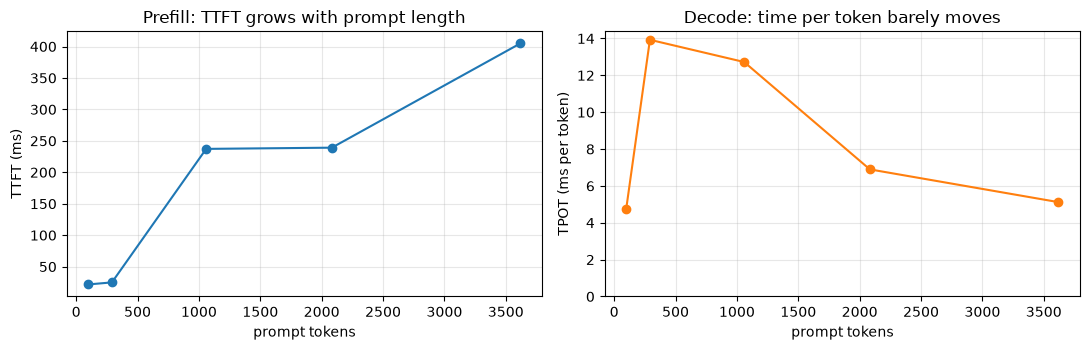

In [6]:
long_row = phases.iloc[-1]
prefill_tok_s, decode_tok_s = long_row["prefill tok/s"], phases["decode tok/s"].median()
weights_bytes = model_meta["size"]
print(f"prefill processes {prefill_tok_s:,.0f} prompt tokens/s; decode produces {decode_tok_s:,.0f} tokens/s "
      f"→ prefill is {prefill_tok_s / decode_tok_s:.0f}× more productive per second")
print(f"decode reads all {weights_bytes / 2**20:.0f} MiB of weights for every token: "
      f"{weights_bytes * decode_tok_s / 1e9:.0f} GB/s of weight traffic for one stream")
print(f"TTFT grows {long_row['TTFT ms (client)'] / phases.iloc[0]['TTFT ms (client)']:.1f}× from {int(phases.iloc[0]['prompt tokens'])} to "
      f"{int(long_row['prompt tokens'])} prompt tokens; TPOT stays between {phases['TPOT ms'].min():.1f} and {phases['TPOT ms'].max():.1f} ms")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(phases["prompt tokens"], phases["TTFT ms (client)"], marker="o")
axes[0].set(xlabel="prompt tokens", ylabel="TTFT (ms)", title="Prefill: TTFT grows with prompt length")
axes[1].plot(phases["prompt tokens"], phases["TPOT ms"], marker="o", color="tab:orange")
axes[1].set(xlabel="prompt tokens", ylabel="TPOT (ms per token)", title="Decode: time per token barely moves", ylim=(0, None))
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the result.** On this run, prefill digested prompt tokens far faster than decode produced output tokens, even though both use the same weights. TTFT scales with the prompt (plus a bit of quadratic attention cost for long prompts), while TPOT does not grow in proportion to the prompt. It wobbles from request to request when other programs share the GPU, and it creeps up for very long contexts because each step also reads a longer KV cache.

That is why the same two levers show up everywhere:
- **Long prompts hurt TTFT** → prefix caching, chunked prefill, shorter prompts.
- **Long outputs hurt total latency** → smaller or quantized weights (fewer bytes to move), speculative decoding (more tokens per weight read), batching (share each weight read across many users).

### ✍️ Your Turn

A server prefills at **5,000 tokens/s** and decodes at **40 ms per token** for one user. Estimate the **end-to-end latency in seconds** of a request with a **3,000-token prompt** and **200 output tokens**. Store it in `estimated_e2e_s`.

In [7]:
estimated_e2e_s = None  # TODO: prefill time + decode time
check("estimated_e2e_s", estimated_e2e_s, 8.6, hint="Prefill: 3000 / 5000 seconds. Decode: 200 × 0.040 seconds.")

⏳ estimated_e2e_s: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
estimated_e2e_s = 3000 / 5000 + 200 * 0.040
check("estimated_e2e_s", estimated_e2e_s, 8.6)
```

Prefill takes 0.6 s and decode takes 8 s. Even with a prompt 15× longer than the output, **decode dominates** end-to-end latency. (The first output token comes out of prefill, so strictly it is 199 decode steps; the estimate is the same to one decimal.)
</details>

> 💡 **Interview angle:** "Why is decoding slow even on a huge GPU?" — each step reads every weight and the whole KV cache to produce one token per sequence, so speed is limited by memory bandwidth, not FLOPs. Batching, quantization and speculative decoding all attack that: more useful tokens per byte moved.

## 2. Serving Metrics: TTFT, TPOT, Throughput, Goodput 🟢

| Metric | Definition | Who cares |
|---|---|---|
| **TTFT** — time to first token | request sent → first token received (queueing + prefill + network) | chat users ("is it thinking?") |
| **TPOT** — time per output token | (E2E − TTFT) / (output tokens − 1) | readers of a stream; below ~50 ms feels faster than reading |
| **ITL** — inter-token latency | gap between *each* pair of consecutive tokens; TPOT is its average | smoothness; spikes show stalls |
| **E2E latency** | request sent → last token | agents, batch jobs, API callers without streaming |
| **Throughput** | output tokens/s (or requests/s) across **all** users | cost per token, capacity |
| **Goodput** | requests/s that **meet the SLO** (e.g. TTFT ≤ 500 ms *and* TPOT ≤ 50 ms) | the only throughput users experience |

An **SLO** (service-level objective) is a target like "p95 TTFT ≤ 1 s". **Percentiles** matter because averages hide the slow requests: p95 = 95% of requests were at least this fast. Latency distributions have long tails, so always report p50 *and* p95/p99.

Below, 12 real conversations run one after another on our one-slot server, each forced to the length of its dataset answer.

 prompt_tokens  output_tokens  ttft_ms  tpot_ms  itl_p99_ms  e2e_s
           289             14    25.73     4.67        5.33   0.09
            40             87    20.14     4.60        5.64   0.42
            68             17    18.06     4.56        5.35   0.09
           246             41    22.03     4.64        5.69   0.21
           335             34    27.89     4.46        5.94   0.18
            66             93    15.32    15.78       38.80   1.47
            98              8    63.50    26.96       38.70   0.25
            46             32    19.36     8.35        9.79   0.28
           133            111    22.10     6.46        9.91   0.73
            74             45    18.83     4.61        5.25   0.22
           264             22    24.30     4.85        5.40   0.13
           251             58    24.27     4.70        5.71   0.29

inter-token gaps over 550 tokens: p50 4.75 ms | p90 9.62 ms | p99 37.03 ms | max 40.44 ms
TTFT p50 22.1 ms | p95 43.9 ms
sequent

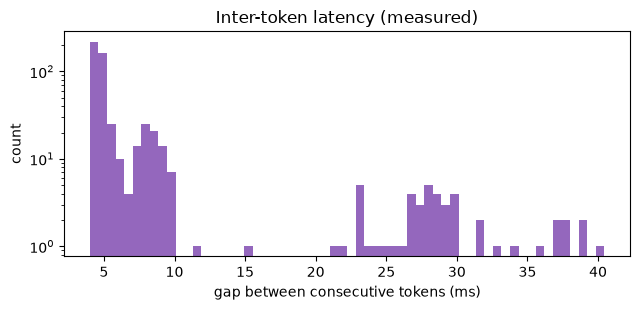

In [8]:
async with httpx.AsyncClient(timeout=300) as client:
    sequential = [await stream_chat(client, srv.api, req["messages"], max_tokens=req["output_tokens"], ignore_eos=True)
                  for req in WORKLOAD[:12]]
seq_df = pd.DataFrame(sequential)
seq_df["itl_p99_ms"] = [np.percentile(itl, 99) if len(itl) else np.nan for itl in seq_df["itl_ms"]]
print(seq_df[["prompt_tokens", "output_tokens", "ttft_ms", "tpot_ms", "itl_p99_ms", "e2e_s"]].round(2).to_string(index=False))

all_itl = np.concatenate(seq_df["itl_ms"].to_list())
print(f"\ninter-token gaps over {len(all_itl)} tokens: p50 {np.percentile(all_itl, 50):.2f} ms | p90 {np.percentile(all_itl, 90):.2f} ms | "
      f"p99 {np.percentile(all_itl, 99):.2f} ms | max {all_itl.max():.2f} ms")
print(f"TTFT p50 {seq_df.ttft_ms.median():.1f} ms | p95 {np.percentile(seq_df.ttft_ms, 95):.1f} ms")
wall = seq_df["e2e_s"].sum()
print(f"sequential throughput: {seq_df.output_tokens.sum() / wall:.0f} output tok/s, {len(seq_df) / wall:.2f} req/s")

SLO = {"ttft_ms": 200, "tpot_ms": 10}                    # EXAMPLE SLO for this tiny model on a laptop
meets = (seq_df.ttft_ms <= SLO["ttft_ms"]) & (seq_df.tpot_ms <= SLO["tpot_ms"])
print(f"goodput under example SLO {SLO}: {meets.sum()} of {len(seq_df)} requests met it → {meets.sum() / wall:.2f} good req/s")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.hist(all_itl, bins=60, color="tab:purple")
ax.set(xlabel="gap between consecutive tokens (ms)", ylabel="count", title="Inter-token latency (measured)", yscale="log")
plt.tight_layout()
plt.show()

**Reasoning models change TTFT.** Models like gpt-oss stream hidden "reasoning" tokens before the visible answer. The first token arrives quickly, but the *first answer token* can arrive seconds later. Measure both. The cell below sends **one** request to the shared large-model server (if it's running) and reads its `/props`, which llama.cpp uses to report its configuration.

In [9]:
if SHARED_LLM_UP:
    shared_root = LLM_BASE_URL.removesuffix("/v1")
    try:
        props = httpx.get(shared_root + "/props", timeout=10).json()
        settings = props.get("default_generation_settings", {})
        print(f"shared server /props: {props.get('total_slots')} slots, n_ctx per slot {settings.get('n_ctx')}, build {props.get('build_info')}")
    except (httpx.HTTPError, ValueError) as err:
        props = {}
        print(f"⏭️ /props not available on this server ({type(err).__name__}) — it may not be llama.cpp")
    async with httpx.AsyncClient(timeout=300) as client:
        big = await stream_chat(client, LLM_BASE_URL, [{"role": "user", "content": "In one sentence, what is a KV cache?"}],
                                max_tokens=512, model=LLM_MODEL, api_key=LLM_API_KEY,
                                chat_template_kwargs={"reasoning_effort": "low"})
    print(f"{LLM_MODEL}: TTFT (first token, reasoning) {big['ttft_ms']:.0f} ms | first ANSWER token {big['first_answer_ms']:.0f} ms | "
          f"TPOT {big['tpot_ms']:.1f} ms | {big['output_tokens']} output tokens incl. reasoning | E2E {big['e2e_s']:.2f} s")
else:
    print(f"⏭️ Skipped: no LLM server at {LLM_BASE_URL}. Start one to compare a 20B reasoning model's TTFT and TPOT with the tiny model.")

shared server /props: 4 slots, n_ctx per slot 8192, build b10809-5266f24da


gpt-oss-20b: TTFT (first token, reasoning) 259 ms | first ANSWER token 536 ms | TPOT 24.8 ms | 60 output tokens incl. reasoning | E2E 1.72 s


### ✍️ Your Turn

A streamed response took **4.2 s** end to end, its first token arrived after **0.2 s**, and it produced **201 output tokens**. Compute its **TPOT in milliseconds** and store it in `tpot_ms`.

In [10]:
tpot_ms = None  # TODO
check("tpot_ms", tpot_ms, 20.0, hint="TPOT = (E2E − TTFT) / (output tokens − 1), then convert seconds to ms.")

⏳ tpot_ms: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tpot_ms = (4.2 - 0.2) / (201 - 1) * 1000
check("tpot_ms", tpot_ms, 20.0)
```

The first token is produced by prefill, so only the remaining 200 tokens share the 4.0 s of decoding.
</details>

In [11]:
srv.stop()

> 💡 **Interview angle:** "Our p50 latency is fine but users complain." — look at p95/p99 TTFT (queueing behind long prompts, cache misses) and ITL spikes (a long prefill stalling everyone's decode). Report **goodput under an SLO**, not raw throughput: a server can double tokens/s while half the requests miss their TTFT target.

## 3. The KV Cache: Memory Math With Real Configs 🟡

In attention, every token produces a **key** and a **value** vector in every layer. During decode, the new token attends to all earlier tokens, so we keep their keys and values instead of recomputing them. That store is the **KV cache**. [Transformers From Scratch](../04_Deep_Learning/03_Transformers_From_Scratch.ipynb) shows the mechanism; the [LLM System Design](../15_Interview_Prep/04_LLM_System_Design.ipynb) notebook works one example end to end. Here we go deeper, across architectures.

$$\text{KV bytes per token} = \underbrace{2}_{K \text{ and } V} \times n_\text{layers} \times n_\text{KV heads} \times d_\text{head} \times \text{bytes per element}$$

It grows **linearly** with context length and with the number of concurrent sequences. Architectures shrink it in different ways:

| Technique | Idea | Effect on the KV cache |
|---|---|---|
| **MHA** (multi-head attention) | every query head has its own K/V head | the baseline, largest |
| **GQA** (grouped-query attention) | many query heads share a few K/V heads | ÷ (query heads / KV heads) |
| **Sliding-window attention (SWA)** | some layers attend only to the last *W* tokens | those layers store at most *W* tokens, whatever the context |
| **MLA** (multi-head latent attention, DeepSeek) | store one small compressed latent per token per layer, rebuild K/V from it | much smaller than even GQA |
| **MoE** (mixture of experts) | only some feed-forward experts run per token | **no change** to the KV cache; it changes weight memory and compute |

Every config below was checked against the model's published `config.json` (the cell re-downloads each file, a few KB, to verify). Gated official repos are read through public mirrors with identical configs.

In [12]:
KV_MODELS = [
    # name, config repo, layers, query heads, KV heads, head_dim, attention notes
    dict(model="Llama-2-7B", repo="NousResearch/Llama-2-7b-hf", layers=32, q_heads=32, kv_heads=32, head_dim=128, attention="MHA"),
    dict(model="Llama-2-70B", repo="NousResearch/Llama-2-70b-hf", layers=80, q_heads=64, kv_heads=8, head_dim=128, attention="GQA"),
    dict(model="Llama-3.1-8B", repo="NousResearch/Meta-Llama-3.1-8B", layers=32, q_heads=32, kv_heads=8, head_dim=128, attention="GQA"),
    dict(model="Qwen2.5-7B", repo="Qwen/Qwen2.5-7B-Instruct", layers=28, q_heads=28, kv_heads=4, head_dim=128, attention="GQA"),
    dict(model="Mistral-7B-v0.1", repo="mistralai/Mistral-7B-v0.1", layers=32, q_heads=32, kv_heads=8, head_dim=128, attention="GQA + SWA 4096 (all layers)"),
    dict(model="Mixtral-8x7B (MoE)", repo="mistralai/Mixtral-8x7B-v0.1", layers=32, q_heads=32, kv_heads=8, head_dim=128, attention="GQA, 8 experts / 2 active"),
    dict(model="Qwen3-30B-A3B (MoE)", repo="Qwen/Qwen3-30B-A3B", layers=48, q_heads=32, kv_heads=4, head_dim=128, attention="GQA, 128 experts / 8 active"),
    dict(model="Gemma-3-27B", repo="unsloth/gemma-3-27b-it", layers=62, q_heads=32, kv_heads=16, head_dim=128, attention="GQA, 5 local (SWA 1024) : 1 global"),
    dict(model="gpt-oss-20b (MoE)", repo="openai/gpt-oss-20b", layers=24, q_heads=64, kv_heads=8, head_dim=64, attention="GQA, alternating SWA 128 / full"),
    dict(model="DeepSeek-V3 (MoE)", repo="deepseek-ai/DeepSeek-V3", layers=61, q_heads=128, kv_heads=128, head_dim=None, attention="MLA: latent 512 + RoPE key 64"),
]


def verify_config(spec):
    try:
        cfg = json.loads(Path(hf_hub_download(spec["repo"], "config.json")).read_text())
    except Exception as err:                                                     # offline → keep the cited values
        return f"⏭️ offline ({type(err).__name__})"
    cfg = cfg.get("text_config", cfg)
    head_dim = cfg.get("head_dim") or cfg["hidden_size"] // cfg["num_attention_heads"]
    got = (cfg["num_hidden_layers"], cfg["num_attention_heads"], cfg["num_key_value_heads"], head_dim)
    want = (spec["layers"], spec["q_heads"], spec["kv_heads"], spec["head_dim"] or head_dim)
    return "✅" if got == want else f"❌ config says {got}"


for spec in KV_MODELS:
    spec["config check"] = verify_config(spec)
print(pd.DataFrame(KV_MODELS)[["model", "layers", "q_heads", "kv_heads", "head_dim", "attention", "config check"]].to_string(index=False))

              model  layers  q_heads  kv_heads  head_dim                          attention config check
         Llama-2-7B      32       32        32     128.0                                MHA            ✅
        Llama-2-70B      80       64         8     128.0                                GQA            ✅
       Llama-3.1-8B      32       32         8     128.0                                GQA            ✅
         Qwen2.5-7B      28       28         4     128.0                                GQA            ✅
    Mistral-7B-v0.1      32       32         8     128.0        GQA + SWA 4096 (all layers)            ✅
 Mixtral-8x7B (MoE)      32       32         8     128.0          GQA, 8 experts / 2 active            ✅
Qwen3-30B-A3B (MoE)      48       32         4     128.0        GQA, 128 experts / 8 active            ✅
        Gemma-3-27B      62       32        16     128.0 GQA, 5 local (SWA 1024) : 1 global            ✅
  gpt-oss-20b (MoE)      24       64         8      64.

Now the memory. Sliding-window layers store at most *W* tokens, and MLA stores one latent of `kv_lora_rank + qk_rope_head_dim` numbers per token per layer (no factor of 2, because K and V are rebuilt from the same latent). All numbers use **16-bit** (2 bytes per element) caches.

In [13]:
def kv_bytes_per_token(n_layers, n_kv_heads, head_dim, bytes_per_element=2):
    return 2 * n_layers * n_kv_heads * head_dim * bytes_per_element


def kv_bytes_for_context(model, context, bytes_per_element=2):
    """16-bit KV cache for one sequence of `context` tokens, respecting sliding windows and MLA."""
    if model == "Mistral-7B-v0.1":
        return kv_bytes_per_token(32, 8, 128, bytes_per_element) * min(context, 4096)
    if model == "Gemma-3-27B":                                        # every 6th layer is global → 10 global, 52 local
        per_layer = kv_bytes_per_token(1, 16, 128, bytes_per_element)
        return per_layer * (10 * context + 52 * min(context, 1024))
    if model.startswith("gpt-oss-20b"):                               # 12 full layers + 12 sliding-window layers (W=128)
        per_layer = kv_bytes_per_token(1, 8, 64, bytes_per_element)
        return per_layer * (12 * context + 12 * min(context, 128))
    if model.startswith("DeepSeek-V3"):                               # MLA latent: (512 + 64) numbers per layer, per token
        return 61 * (512 + 64) * bytes_per_element * context
    spec = next(s for s in KV_MODELS if s["model"] == model)
    return kv_bytes_per_token(spec["layers"], spec["kv_heads"], spec["head_dim"], bytes_per_element) * context


rows = []
for spec in KV_MODELS:
    full_attention_per_token = 2 * spec["layers"] * spec["q_heads"] * (spec["head_dim"] or 128) * 2   # if it had plain MHA everywhere
    rows.append({"model": spec["model"],
                 "KiB/token @4K": kv_bytes_for_context(spec["model"], 4096) / 4096 / 2**10,
                 "GiB @4K": kv_bytes_for_context(spec["model"], 4096) / 2**30,
                 "GiB @32K": kv_bytes_for_context(spec["model"], 32_768) / 2**30,
                 "×smaller than plain MHA @32K": full_attention_per_token * 32_768 / kv_bytes_for_context(spec["model"], 32_768)})
kv_table = pd.DataFrame(rows)
print(kv_table.round(2).to_string(index=False))

llama2_7b_2048 = kv_bytes_for_context("Llama-2-7B", 2048)
print(f"\nLlama-2-7B, one 2,048-token sequence: {llama2_7b_2048 / 2**30:.2f} GiB  (not 33.5 MB — that figure forgot the layers and heads)")
wrong_70b = kv_bytes_per_token(80, 64, 128) / kv_bytes_per_token(80, 8, 128)
print(f"Llama-2-70B modeled with 64 KV heads instead of its real 8 overestimates the cache {wrong_70b:.0f}×")

              model  KiB/token @4K  GiB @4K  GiB @32K  ×smaller than plain MHA @32K
         Llama-2-7B         512.00     2.00     16.00                          1.00
        Llama-2-70B         320.00     1.25     10.00                          8.00
       Llama-3.1-8B         128.00     0.50      4.00                          4.00
         Qwen2.5-7B          56.00     0.22      1.75                          7.00
    Mistral-7B-v0.1         128.00     0.50      0.50                         32.00
 Mixtral-8x7B (MoE)         128.00     0.50      4.00                          4.00
Qwen3-30B-A3B (MoE)          96.00     0.38      3.00                          8.00
        Gemma-3-27B         184.00     0.72      2.91                         10.67
  gpt-oss-20b (MoE)          24.75     0.10      0.75                         15.94
  DeepSeek-V3 (MoE)          68.62     0.27      2.14                         56.89

Llama-2-7B, one 2,048-token sequence: 1.00 GiB  (not 33.5 MB — that figure 

**What to notice:**
- **GQA is why modern 70B models are servable.** Llama-2-70B stores less per token than Llama-2-7B, which uses plain MHA.
- **MoE doesn't shrink the cache.** Mixtral-8x7B has the same attention as Mistral-7B, so the same KV per token (ignoring the sliding window), even though it has ~47B parameters.
- **Sliding windows cap growth.** Gemma 3 and gpt-oss keep full attention only in some layers, so their cache at 32K is a fraction of an all-global design.
- **MLA is the most aggressive**: DeepSeek-V3 (671B total parameters) needs less KV cache per token than Llama-3.1-8B.

### ✍️ Your Turn

Llama-3.1-70B has **80 layers**, **64 query heads**, **8 KV heads**, and **head_dim 128**. How many bytes of **16-bit** KV cache does it need **per token**? Store an integer in `llama31_70b_kv_bytes`.

In [14]:
llama31_70b_kv_bytes = None  # TODO
check("llama31_70b_kv_bytes", llama31_70b_kv_bytes, 327_680, hint="Use the KV heads (8), not the query heads: 2 × 80 × 8 × 128 × 2.")

⏳ llama31_70b_kv_bytes: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
llama31_70b_kv_bytes = kv_bytes_per_token(n_layers=80, n_kv_heads=8, head_dim=128, bytes_per_element=2)
check("llama31_70b_kv_bytes", llama31_70b_kv_bytes, 327_680)
```

320 KiB per token, so a 128K-token context needs ~39 GiB for **one** sequence. Long context is a memory problem long before it is a compute problem.
</details>

> 💡 **Interview angle:** "How much KV cache does a 32K request on Llama-3.1-8B need?" — say the formula out loud, use **KV heads** not attention heads: 2 × 32 × 8 × 128 × 2 bytes = 128 KiB/token → 4 GiB per 32K sequence. Then mention the levers: GQA/MLA (architecture), KV quantization (FP8 halves it), sliding windows, paged allocation, prefix sharing.

## 4. Batching: Static vs Continuous, Measured 🟡

Decode is memory-bandwidth-bound, so running **several sequences in one forward pass** is almost free: the weights are read once and the tiny extra arithmetic fits in the same pass. That is **batching**. The question is *when* requests may join and leave the batch.

```
STATIC batching (batch of 4, one long request)       CONTINUOUS batching (4 slots)
 slot 0  ████░░░░░░░░░░░░  done, but waits              slot 0  ████▓▓▓▓▓▓▒▒▒▒▒▒  new requests join
 slot 1  ████████████████  the long one                 slot 1  ████████████████  as soon as a slot frees
 slot 2  ██████░░░░░░░░░░  done, but waits              slot 2  ██████▓▓▓▓▓▓▓▓▓▓
 slot 3  ███░░░░░░░░░░░░░  done, but waits              slot 3  ███▓▓▓▓▓▒▒▒▒▒▒▒▒
 queue   waits for ALL four to finish ⏳                queue   drains continuously ✅
```

**Continuous batching** (also "in-flight" or iteration-level batching, introduced by the Orca paper) re-plans the batch **at every decode step**. Every modern engine does it. llama.cpp enables it by default and lets us switch it off with `--no-cont-batching`, which makes a busy server wait for the whole running batch to finish before admitting new requests. That lets us measure the difference on **the same trace**: 32 real conversations arriving at once.

In [15]:
BATCH_TRACE = WORKLOAD[:32]
batching_configs = [
    ("1 slot (no batching)", 1, []),
    ("8 slots, static", 8, ["--no-cont-batching"]),
    ("8 slots, continuous", 8, []),
]
batching_rows, batching_requests = [], {}
for label, slots, extra in batching_configs:
    with LlamaServer(TARGET_F16, n_parallel=slots, ctx_per_slot=1024, extra=extra, name="batching") as server:
        await load_test(server.api, WORKLOAD[-4:], concurrency=slots)                     # warm-up with other requests
        summary, per_request = await load_test(server.api, BATCH_TRACE, concurrency=len(BATCH_TRACE))
    batching_rows.append({"config": label, **summary})
    batching_requests[label] = per_request

batch_df = pd.DataFrame(batching_rows)
print(batch_df[["config", "wall_s", "output_tok_per_s", "ttft_p50_ms", "ttft_p95_ms", "tpot_p50_ms", "e2e_p50_s", "e2e_p95_s"]].round(1).to_string(index=False))
static, continuous = batch_df.iloc[1], batch_df.iloc[2]
print(f"\ncontinuous vs static on the same trace: throughput ×{continuous.output_tok_per_s / static.output_tok_per_s:.2f}, "
      f"median E2E {static.e2e_p50_s:.2f}s → {continuous.e2e_p50_s:.2f}s, p95 TTFT {static.ttft_p95_ms:.0f} → {continuous.ttft_p95_ms:.0f} ms")
print(f"batching at all (8 continuous slots vs 1 slot): throughput ×{continuous.output_tok_per_s / batch_df.iloc[0].output_tok_per_s:.1f}")

              config  wall_s  output_tok_per_s  ttft_p50_ms  ttft_p95_ms  tpot_p50_ms  e2e_p50_s  e2e_p95_s
1 slot (no batching)    15.3             121.1       8570.6      14847.6          8.3        8.9       15.0
     8 slots, static     9.2             202.4       2695.9       6888.2         17.5        3.7        9.2
 8 slots, continuous     8.4             222.2       2012.7       6385.1         31.6        3.9        8.2

continuous vs static on the same trace: throughput ×1.10, median E2E 3.67s → 3.93s, p95 TTFT 6888 → 6385 ms
batching at all (8 continuous slots vs 1 slot): throughput ×1.8


Next: **how many slots?** More slots raise throughput but make every step a little slower (each forward pass carries more tokens) and reserve more KV memory. We sweep the slot count with 32 requests in flight, so the server is always saturated, and record the per-token latency at each batch size. The Build It section reuses these timings to drive a scheduler simulation.

 slots  output_tok_per_s  tpot_p50_ms  ttft_p50_ms  e2e_p50_s
     1              94.4         10.5      11051.5       12.1
     2             157.6         13.0       6015.1        6.9
     4             152.2         24.5       5286.1        7.1
     8             342.7         17.9       1479.1        3.0
    16             304.6         32.3        360.4        2.8

1 → 16 slots: throughput ×3.2, median TPOT ×3.1, median TTFT ×0.03


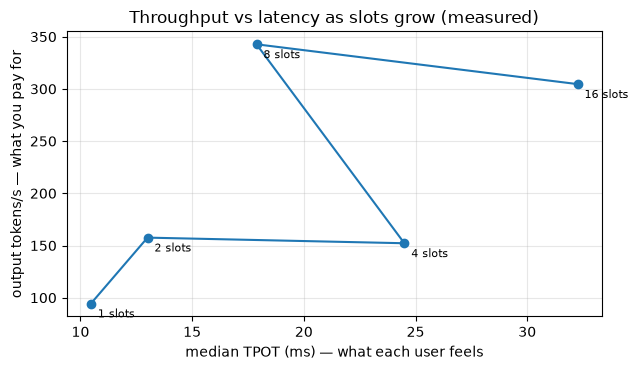

In [16]:
slot_rows = []
for slots in (1, 2, 4, 8, 16):
    with LlamaServer(TARGET_F16, n_parallel=slots, ctx_per_slot=1024, name="slots") as server:
        await load_test(server.api, WORKLOAD[-4:], concurrency=min(slots, 4))
        summary, per_request = await load_test(server.api, WORKLOAD[32:64], concurrency=32)
    slot_rows.append({"slots": slots, **summary})
slot_df = pd.DataFrame(slot_rows)
print(slot_df[["slots", "output_tok_per_s", "tpot_p50_ms", "ttft_p50_ms", "e2e_p50_s"]].round(1).to_string(index=False))

first, last = slot_df.iloc[0], slot_df.iloc[-1]
print(f"\n1 → 16 slots: throughput ×{last.output_tok_per_s / first.output_tok_per_s:.1f}, median TPOT ×{last.tpot_p50_ms / first.tpot_p50_ms:.1f}, "
      f"median TTFT ×{last.ttft_p50_ms / first.ttft_p50_ms:.2f}")
DECODE_STEP_MS = dict(zip(slot_df["slots"], slot_df["tpot_p50_ms"]))        # measured ms per decode step at each batch size
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(slot_df["tpot_p50_ms"], slot_df["output_tok_per_s"], marker="o")
for _, row in slot_df.iterrows():
    ax.annotate(f"{int(row['slots'])} slots", (row["tpot_p50_ms"], row["output_tok_per_s"]), xytext=(5, -10), textcoords="offset points", fontsize=8)
ax.set(xlabel="median TPOT (ms) — what each user feels", ylabel="output tokens/s — what you pay for",
       title="Throughput vs latency as slots grow (measured)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the result.** Static batching holds every slot until the longest request in its batch finishes, so newcomers wait. Continuous batching refills slots immediately, which mostly shows up as shorter waits (TTFT) and a shorter total time for the trace; compare the rows above. More slots raised throughput and cut waiting time (TTFT), while each user's TPOT rose: the classic batching trade-off. When other programs share the GPU, individual numbers (even medians) can flip between runs, so run a benchmark twice and look at the overall trend. You pick the operating point from an SLO, not from maximum throughput.

Two more ideas complete the picture:
- **Chunked prefill.** A 30K-token prompt entering a running batch would stall every user's decode for the whole prefill. Engines split long prefills into chunks and mix them with decode steps (vLLM enables chunked prefill by default; llama.cpp splits prompts into `--ubatch-size` pieces).
- **Prefill/decode disaggregation.** Very large deployments run prefill and decode on **separate** GPU pools (DistServe, Splitwise; supported in vLLM, SGLang and NVIDIA Dynamo), so heavy prompts can't hurt streaming users.

### ✍️ Your Turn

A **static** batch holds four requests that need **12, 80, 30 and 200** output tokens. The batch runs until the longest finishes. What **fraction of the batch's decode slots is wasted** (a slot is wasted when its request has already finished)? Store it in `static_waste`.

In [17]:
lengths_in_batch = [12, 80, 30, 200]
static_waste = None  # TODO
check("static_waste", static_waste, 0.5975, hint="Slots = batch size × longest length. Useful = sum of lengths. Waste = 1 − useful / slots.")

⏳ static_waste: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
lengths_in_batch = [12, 80, 30, 200]
static_waste = 1 - sum(lengths_in_batch) / (len(lengths_in_batch) * max(lengths_in_batch))
check("static_waste", static_waste, 0.5975)
```

322 useful token-steps out of 800: ~60% of the batch capacity does nothing. Real output lengths are long-tailed, so static batching wastes a lot; continuous batching fills those slots with new requests.
</details>

> 💡 **Interview angle:** "Explain continuous batching." — schedule at the granularity of **one decode step**: finished sequences leave and queued ones join immediately, so no slot idles waiting for the longest request. Pair it with paged KV memory (so joining and leaving doesn't fragment memory) and chunked prefill (so long prompts don't stall decodes).

## 5. Paged KV Memory and Prefix Caching 🟡

### Paged KV memory (PagedAttention)

Early servers reserved one **contiguous** KV region per request, sized for the **maximum** context, because they couldn't know the final length. Most of it sat empty. **PagedAttention** (the vLLM paper) borrows the operating-system idea of virtual memory: the cache is split into fixed-size **blocks** (e.g. 16 tokens), a per-request **block table** maps logical positions to physical blocks, and blocks are allocated only as tokens arrive. Waste falls to less than one block per sequence, and identical blocks can be **shared** between requests.

Let's quantify it with our real workload's lengths and a 4,096-token maximum context.

In [18]:
seq_lengths = np.array([r["prompt_tokens"] + r["output_tokens"] for r in WORKLOAD])
MAX_CONTEXT, BLOCK = 4096, 16
contiguous_tokens = len(seq_lengths) * MAX_CONTEXT
paged_tokens = int((np.ceil(seq_lengths / BLOCK) * BLOCK).sum())
print(f"{len(seq_lengths)} real sequences, mean length {seq_lengths.mean():.0f} tokens")
print(f"contiguous reservation: {contiguous_tokens:,} token slots → {1 - seq_lengths.sum() / contiguous_tokens:.1%} wasted")
print(f"paged (block={BLOCK})   : {paged_tokens:,} token slots → {1 - seq_lengths.sum() / paged_tokens:.1%} wasted")
print(f"→ in the same memory, paging fits about {contiguous_tokens / paged_tokens:.0f}× more sequences of this workload")

128 real sequences, mean length 204 tokens
contiguous reservation: 524,288 token slots → 95.0% wasted
paged (block=16)   : 26,992 token slots → 3.4% wasted
→ in the same memory, paging fits about 19× more sequences of this workload


### Prefix caching

Many requests start with the **same tokens**: a long system prompt, few-shot examples, a document everyone asks about, or an earlier chat history. Their KV cache is identical, so a server can keep it and **skip that part of prefill**.

| Engine | How it reuses prefixes |
|---|---|
| **vLLM** | automatic prefix caching (on by default in current versions): each full block is hashed together with everything before it; matching blocks are shared, and LRU eviction frees them |
| **SGLang** | RadixAttention: a radix tree of token sequences, great for branching agent and tool-call trees |
| **llama.cpp** | each slot keeps its last prompt (`cache_prompt`, on by default); `--cache-reuse N` can reuse shifted chunks, `--cache-ram` keeps extra prompts in host RAM |
| **Hosted APIs** | "prompt caching" (automatic or with explicit cache markers), often billed at a discount for cached input tokens |

**The rule for developers:** put **stable content first** (instructions, tools, documents) and **variable content last** (the user question, timestamps, IDs). One changed token at the start invalidates everything after it.

We measure it: a real ~3,000-token Wikipedia excerpt followed by six different questions, with the cache disabled and then enabled.

In [19]:
document = TOKENIZER.decode(WIKI_IDS[20_000:23_000])
questions = ["Who is this text about?", "Summarize the first paragraph.", "List three dates mentioned.",
             "What is the main topic?", "Name one place mentioned.", "Is the tone neutral?"]
prefix_rows = []
with LlamaServer(TARGET_F16, n_parallel=1, ctx_per_slot=4096, name="prefix") as server:
    async with httpx.AsyncClient(timeout=300) as client:
        await stream_chat(client, server.api, [{"role": "user", "content": "Hi"}], max_tokens=4)
        for cache_on in (False, True):
            for q in questions:
                messages = [{"role": "system", "content": "Answer using this document:\n" + document},
                            {"role": "user", "content": q}]
                result = await stream_chat(client, server.api, messages, max_tokens=16, cache_prompt=cache_on)
                prefix_rows.append({"cache_prompt": cache_on, "question": q, "prompt tokens": result["prompt_tokens"],
                                    "cached tokens": result["cached_tokens"], "TTFT ms": result["ttft_ms"]})
prefix_df = pd.DataFrame(prefix_rows)
print(prefix_df.round(1).to_string(index=False))

ttft_off = prefix_df[~prefix_df.cache_prompt]["TTFT ms"].iloc[1:].median()
ttft_on = prefix_df[prefix_df.cache_prompt]["TTFT ms"].iloc[1:].median()        # skip the first: it fills the cache
print(f"\nmedian TTFT, requests 2-6: cache off {ttft_off:.0f} ms → cache on {ttft_on:.0f} ms (×{ttft_off / ttft_on:.1f} faster)")

 cache_prompt                       question  prompt tokens  cached tokens  TTFT ms
        False        Who is this text about?           3026              0    563.7
        False Summarize the first paragraph.           3027              0    588.1
        False    List three dates mentioned.           3025              0    610.7
        False        What is the main topic?           3026              0    604.0
        False      Name one place mentioned.           3025              0    534.8
        False           Is the tone neutral?           3025              0    576.0
         True        Who is this text about?           3026           3014    119.2
         True Summarize the first paragraph.           3027           3014     68.2
         True    List three dates mentioned.           3025           3014     41.2
         True        What is the main topic?           3026           3014     38.8
         True      Name one place mentioned.           3025           3014  

**Reading the result.** With caching on, requests 2–6 reported almost all prompt tokens as `cached tokens`, and TTFT fell accordingly on this run. For a 360M model on a laptop, prefill is already fast, so the absolute saving is milliseconds. For a 70B model with a 30K-token document, the same ratio saves **seconds** per request and a large share of GPU compute.

### ✍️ Your Turn

With a block size of **16**, how many KV blocks does a **1,000-token** sequence need, and how many token slots in its last block are **unused**? Store a tuple `(blocks, unused_slots)` in `paged_answer`.

In [20]:
paged_answer = None  # TODO: (blocks, unused_slots)
check("paged_answer", paged_answer, (63, 8), hint="blocks = ceil(1000 / 16); unused = blocks × 16 − 1000.")

⏳ paged_answer: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
blocks = math.ceil(1000 / 16)
paged_answer = (blocks, blocks * 16 - 1000)
check("paged_answer", paged_answer, (63, 8))
```

Waste is always less than one block per sequence: that is the whole point of paging.
</details>

> 💡 **Interview angle:** "How would you cut TTFT for a RAG chatbot with a 4K-token system prompt?" — put the static instructions first so the engine's **prefix cache** hits (vLLM APC / SGLang RadixAttention / provider prompt caching), keep per-request data at the end, route a user's requests to the same replica (cache-aware or session-affinity routing), and measure `cached_tokens` to prove it.

## 6. Quantization: Formats, Size, Speed, and Quality 🟡

**Quantization** stores numbers with fewer bits. For LLMs that mostly means the **weights** (sometimes activations and the KV cache too). Fewer bytes per weight means a smaller model, more room for KV cache, and faster decode, because decode is limited by how many bytes move per token. The price is some loss of quality, which you must **measure**.

| Format | Bits per weight | What it is | Where it runs |
|---|---|---|---|
| **FP32** | 32 | full precision; training master weights | everywhere, rarely used for serving |
| **FP16 / BF16** | 16 | half precision; BF16 keeps FP32's range (no overflow) with less precision | the default for serving on GPUs |
| **INT8** (LLM.int8, SmoothQuant W8A8) | 8 | 8-bit integers with scales; W8A8 also quantizes activations | GPUs and CPUs; near-lossless for most models |
| **FP8** (E4M3 / E5M2) | 8 | 8-bit floating point for weights, activations and often the KV cache | NVIDIA Ada/Hopper/Blackwell and recent AMD GPUs; common in vLLM, SGLang, TensorRT-LLM |
| **GPTQ** | 3–4 (+ scales) | post-training quantization that corrects errors layer by layer using second-order (Hessian) information from calibration data | GPU kernels (vLLM, TGI, Transformers) |
| **AWQ** | 4 (+ scales) | activation-aware: protects the most important weight channels, found from calibration activations, by scaling before quantizing | GPU kernels (vLLM, SGLang, TensorRT-LLM) |
| **GGUF k-quants** (Q8_0, Q6_K, Q4_K_M, Q2_K…) | ~2.6–8.5 | llama.cpp's block formats: small blocks share a scale (and minimum); `_S/_M/_L` mix precisions, keeping sensitive tensors at more bits | llama.cpp, Ollama, LM Studio (CPU, Metal, CUDA, Vulkan) |
| **MXFP4** | ~4.25 | OCP "microscaling" 4-bit float (E2M1): 32 values share one 8-bit power-of-two scale; gpt-oss ships its MoE expert weights this way | vLLM, llama.cpp, Transformers (fastest on newer GPUs) |
| **NVFP4** | ~4.5 | NVIDIA 4-bit float with 16-value blocks and FP8 scales | NVIDIA Blackwell |

**Weight-only vs weight-and-activation.** Weight-only formats (GPTQ, AWQ, GGUF, MXFP4) mainly speed up **decode**, because fewer bytes move per token; the matrix math still runs in 16-bit after unpacking. Formats that also quantize activations (W8A8 INT8, FP8, NVFP4) can speed up **prefill** too, but only on hardware with the right kernels.

Now let's measure on our target model. We create 8-, 4- and 2-bit GGUF files **from the 16-bit file** with `llama-quantize` (seconds each). Then:
- `llama-bench` measures prefill (`pp512`: a 512-token prompt) and decode (`tg128`: 128 generated tokens) speed, repeated 3 times.
- `llama-perplexity` measures **perplexity** on 20K tokens of WikiText-2 test text. Perplexity is exp(average negative log-likelihood per token): how "surprised" the model is by real text. Lower is better, and the change versus FP16 is what matters.

In [21]:
QUANT_FILES = {"F16": TARGET_F16}
for qtype in ("Q8_0", "Q4_K_M", "Q2_K"):
    out_path = MODEL_DIR / f"SmolLM2-360M-Instruct-{qtype}.gguf"
    if not out_path.exists():
        start = time.perf_counter()
        result = subprocess.run(["llama-quantize", str(TARGET_F16), str(out_path), qtype], capture_output=True, text=True)
        if result.returncode != 0:
            raise RuntimeError(result.stderr[-1000:])
        size_line = re.search(r"quant size\s*=\s*(.*)", result.stdout + result.stderr).group(1)
        print(f"llama-quantize → {qtype:6s} in {time.perf_counter() - start:.1f} s: {size_line}")
    else:
        print(f"{qtype:6s} already created ({out_path.stat().st_size / 2**20:.0f} MiB)")
    QUANT_FILES[qtype] = out_path


def llama_bench(path, reps=5):
    out = subprocess.run(["llama-bench", "-m", str(path), "-p", "512", "-n", "128", "-r", str(reps), "-o", "json"],
                         capture_output=True, text=True, check=True)
    tests = json.loads(out.stdout)
    pp = next(t for t in tests if t["n_prompt"] > 0 and t["n_gen"] == 0)
    tg = next(t for t in tests if t["n_gen"] > 0 and t["n_prompt"] == 0)
    return {"size MiB": pp["model_size"] / 2**20, "bits/weight": pp["model_size"] * 8 / pp["model_n_params"],
            "prefill tok/s": pp["avg_ts"], "prefill ±": pp["stddev_ts"], "decode tok/s": tg["avg_ts"], "decode ±": tg["stddev_ts"]}


def llama_perplexity(path, chunks=40, ctx=512):
    out = subprocess.run(["llama-perplexity", "-m", str(path), "-f", str(WIKI_FILE), "-c", str(ctx), "--chunks", str(chunks)],
                         capture_output=True, text=True, check=True)
    match = re.search(r"Final estimate: PPL = ([\d.]+) \+/- ([\d.]+)", out.stdout + out.stderr)
    return float(match.group(1)), float(match.group(2))


quant_rows = []
for name, path in QUANT_FILES.items():
    ppl, ppl_err = llama_perplexity(path)
    quant_rows.append({"format": name, **llama_bench(path), "perplexity": ppl, "ppl ±": ppl_err})
quant_table = pd.DataFrame(quant_rows).set_index("format")
base = quant_table.loc["F16"]
quant_table["Δ perplexity %"] = (quant_table["perplexity"] / base["perplexity"] - 1) * 100
quant_table["decode speedup"] = quant_table["decode tok/s"] / base["decode tok/s"]
quant_table["GB/s of weights read in decode"] = quant_table["size MiB"] * 2**20 * quant_table["decode tok/s"] / 1e9
print(quant_table.round(2).to_string())

Q8_0   already created (369 MiB)
Q4_K_M already created (258 MiB)
Q2_K   already created (209 MiB)


        size MiB  bits/weight  prefill tok/s  prefill ±  decode tok/s  decode ±  perplexity  ppl ±  Δ perplexity %  decode speedup  GB/s of weights read in decode
format                                                                                                                                                            
F16       690.24        16.00       10700.86    2568.84         80.01      2.25       13.81   0.39            0.00            1.00                           57.91
Q8_0      366.80         8.50        7389.76     853.73         94.33     11.72       13.82   0.39            0.07            1.18                           36.28
Q4_K_M    256.35         5.94       14353.86    2576.03        124.51      5.60       14.10   0.40            2.14            1.56                           33.47
Q2_K      206.84         4.80        9563.80     665.86        128.53      9.75       16.70   0.47           20.95            1.61                           27.88


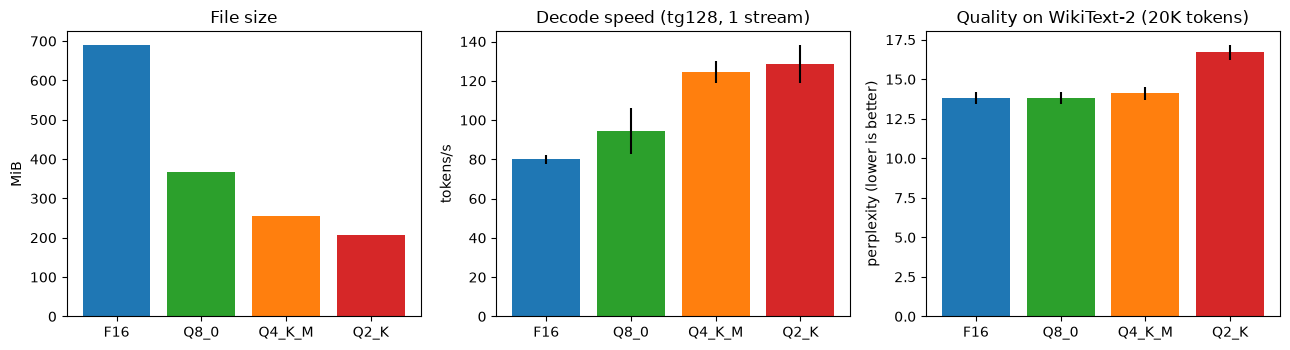

smallest format within 5% of FP16 perplexity on this run: Q4_K_M (256 MiB, +2.1% perplexity)
Q2_K: 30% of the FP16 size but +21% perplexity


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
colors = ["tab:blue", "tab:green", "tab:orange", "tab:red"]
axes[0].bar(quant_table.index, quant_table["size MiB"], color=colors)
axes[0].set(ylabel="MiB", title="File size")
axes[1].bar(quant_table.index, quant_table["decode tok/s"], yerr=quant_table["decode ±"], color=colors)
axes[1].set(ylabel="tokens/s", title="Decode speed (tg128, 1 stream)")
axes[2].bar(quant_table.index, quant_table["perplexity"], yerr=quant_table["ppl ±"], color=colors)
axes[2].set(ylabel="perplexity (lower is better)", title="Quality on WikiText-2 (20K tokens)")
plt.tight_layout()
plt.show()

best_small = quant_table[quant_table["Δ perplexity %"] <= 5].sort_values("size MiB").index[0]
print(f"smallest format within 5% of FP16 perplexity on this run: {best_small} "
      f"({quant_table.loc[best_small, 'size MiB']:.0f} MiB, {quant_table.loc[best_small, 'Δ perplexity %']:+.1f}% perplexity)")
print(f"Q2_K: {quant_table.loc['Q2_K', 'size MiB'] / base['size MiB']:.0%} of the FP16 size but {quant_table.loc['Q2_K', 'Δ perplexity %']:+.0f}% perplexity")

**Reading the result.**
- **Bits per weight are higher than the names suggest** for this small model. Its embedding table is a big share of its parameters and is kept at higher precision, so "Q4_K_M" lands near 6 bits/weight here. On a 7B+ model, Q4_K_M is close to 4.8 bits/weight.
- **Decode speed follows size, but not perfectly.** Fewer bytes per token usually means faster decode. Unpacking (dequantizing) blocks costs compute, and for a model this small on a GPU, fixed per-token overhead matters, so check the measured `decode speedup` column rather than assuming it. The "GB/s of weights read" column shows how much memory traffic each format produces.
- **Quality degrades gently until it doesn't.** 8-bit is usually indistinguishable from FP16, 4-bit k-quants cost a little, and 2-bit hurts a lot, especially for small models. Large models tolerate low bits better.
- **Perplexity is a first check, not the final word.** Also run your task evals (accuracy on your golden set, code tests, JSON validity), and check sensitive slices: math, code, non-English text, long context.

### ✍️ Your Turn

Estimate the file size in **GiB** of an **8.03-billion-parameter** model quantized to an average of **4.5 bits per weight**. Store it in `size_gib`.

In [23]:
size_gib = None  # TODO
check("size_gib", size_gib, 4.2069, hint="bytes = params × bits / 8; GiB = bytes / 2**30.")

⏳ size_gib: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
size_gib = 8.03e9 * 4.5 / 8 / 2**30
check("size_gib", size_gib, 4.2069)
```

The same model in BF16 is ~15 GiB. Quantization often decides whether a model fits on a single GPU, with room left for the KV cache.
</details>

> 💡 **Interview angle:** "AWQ, GPTQ, FP8 or GGUF?" — FP8 (W8A8) on modern NVIDIA GPUs when you want near-lossless quality **and** faster prefill; AWQ/GPTQ 4-bit when memory is tight and decode speed matters; GGUF k-quants for llama.cpp on CPUs, Macs and edge devices; always compare against the 16-bit baseline on **your** evals, not just perplexity.

## 7. Speculative Decoding 🔴

Decode wastes most of each forward pass: a pass that could check many tokens produces only one. **Speculative decoding** fixes that:

1. A cheap **drafter** proposes the next γ tokens (a small model, n-gram lookups in the prompt, or extra prediction heads like Medusa/EAGLE/MTP).
2. The big **target** model scores all γ proposals in **one** forward pass, which costs about the same as one normal decode step because decode is memory-bound.
3. Proposals are accepted left to right while they agree with the target; at the first disagreement the target's own token is used.

With the right acceptance rule (greedy match, or rejection sampling for random sampling), the output distribution is **exactly** the target model's. The speedup depends on α, the probability a drafted token is accepted, and c, the drafter's cost relative to the target (Leviathan et al., 2023):

$$\mathbb{E}[\text{tokens per target pass}] = \frac{1-\alpha^{\gamma+1}}{1-\alpha} \qquad \text{speedup} \approx \frac{1-\alpha^{\gamma+1}}{(1-\alpha)(\gamma c + 1)}$$

It helps most when the target is large, the drafter is tiny, text is predictable (code, edits, extraction), and batches are small. At high batch sizes the GPU is already doing useful parallel work, so the gain shrinks.

llama.cpp supports a draft model (`-md draft.gguf --spec-type draft-simple`) and draft-free n-gram methods (`--spec-type ngram-simple`, which reuses text already in the context). We measure both on two real tasks: writing new code, and correcting typos in a real Wikipedia paragraph (where the output mostly copies the input).

In [24]:
wiki_paragraphs = [line.strip() for line in wikitext["text"] if 400 < len(line.strip()) < 700]
paragraph = wiki_paragraphs[3]
typo_paragraph = " ".join(w[:-2] + w[-1] + w[-2] if i % 10 == 5 and len(w) > 4 and w.isalpha() else w
                          for i, w in enumerate(paragraph.split(" ")))
SPEC_TASKS = {
    "write new code": "Write a Python function is_prime(n) with a docstring and three doctest examples.",
    "fix typos in given text": "Fix the spelling mistakes and return the full corrected paragraph only:\n\n" + typo_paragraph,
}
SPEC_CONFIGS = {                                                    # label → (model file, extra llama-server flags)
    "target only (360M F16)": (TARGET_F16, []),
    "draft model alone (135M Q8_0)": (DRAFT_Q8, []),                 # measured right after the target: the drafter's own cost
    "+ draft model (135M Q8_0)": (TARGET_F16, ["-md", DRAFT_Q8, "--spec-type", "draft-simple", "--spec-draft-n-max", "4"]),
    "+ n-gram lookup (no extra model)": (TARGET_F16, ["--spec-type", "ngram-simple", "--spec-ngram-simple-size-n", "3",
                                                      "--spec-ngram-simple-size-m", "8"]),
}
REPEATS = 3                                                         # medians of 3 runs smooth out noise from other GPU users
spec_runs = []
for config, (model_path, extra) in SPEC_CONFIGS.items():
    with LlamaServer(model_path, n_parallel=1, ctx_per_slot=2048, extra=extra, name="speculative") as server:
        httpx.post(server.api + "/chat/completions", json={"messages": [{"role": "user", "content": "Hi"}], "max_tokens": 8}, timeout=60)
        for task, prompt in SPEC_TASKS.items():
            for _ in range(REPEATS):
                reply = httpx.post(server.api + "/chat/completions", timeout=120, json={
                    "messages": [{"role": "user", "content": prompt}], "max_tokens": 192, "temperature": 0}).json()
                t = reply["timings"]
                spec_runs.append({"task": task, "config": config, "tokens": t["predicted_n"], "ms/token": t["predicted_per_token_ms"],
                                  "drafted": t.get("draft_n", 0), "accepted": t.get("draft_n_accepted", 0),
                                  "text": reply["choices"][0]["message"]["content"]})
spec_df = (pd.DataFrame(spec_runs).groupby(["task", "config"], sort=False)
           .agg(**{"tokens": ("tokens", "median"), "ms/token": ("ms/token", "median"), "ms/token min": ("ms/token", "min"),
                   "ms/token max": ("ms/token", "max"), "drafted": ("drafted", "sum"), "accepted": ("accepted", "sum"),
                   "text": ("text", "first")}).reset_index())
spec_df["acceptance"] = (spec_df["accepted"] / spec_df["drafted"].replace(0, np.nan)).round(2)
baseline = spec_df[spec_df.config.str.startswith("target only")].set_index("task")
spec_df["speedup"] = [baseline.loc[r.task, "ms/token"] / r["ms/token"] for _, r in spec_df.iterrows()]
spec_df["same text as target"] = [r.text == baseline.loc[r.task, "text"] for _, r in spec_df.iterrows()]
spec_view = spec_df[~spec_df.config.str.startswith("draft model alone")]
print(spec_view.drop(columns="text").round(2).to_string(index=False))

                   task                           config  tokens  ms/token  ms/token min  ms/token max  drafted  accepted  acceptance  speedup  same text as target
         write new code           target only (360M F16)   192.0     12.30         10.63         13.28        0         0         NaN     1.00                 True
fix typos in given text           target only (360M F16)    99.0     12.04         11.55         12.81        0         0         NaN     1.00                 True
         write new code        + draft model (135M Q8_0)   192.0     13.27         11.28         16.94      528       441        0.84     0.93                 True
fix typos in given text        + draft model (135M Q8_0)    99.0     12.08          9.35         12.53      300       231        0.77     1.00                 True
         write new code + n-gram lookup (no extra model)   192.0      7.86          6.96          9.59      336        84        0.25     1.56                 True
fix typos in giv

Does the formula explain what we saw? We need c, the drafter's per-token cost relative to the target. We measured it on the same server path ("draft model alone") and now plug in the measured acceptance rates. (The acceptance fraction reported by the server is only an approximation of the paper's per-token α.)

In [25]:
def expected_speedup(alpha, gamma, c):
    tokens_per_pass = (1 - alpha ** (gamma + 1)) / (1 - alpha) if alpha < 1 else gamma + 1
    return tokens_per_pass / (gamma * c + 1)


target_ms = spec_df[spec_df.config.str.startswith("target only")].set_index("task")["ms/token"]
draft_ms = spec_df[spec_df.config.str.startswith("draft model alone")].set_index("task")["ms/token"]
for task in SPEC_TASKS:
    c_task = draft_ms[task] / target_ms[task]
    row = spec_df[(spec_df.task == task) & spec_df.config.str.startswith("+ draft")].iloc[0]
    predicted = expected_speedup(row.acceptance, 4, c_task)
    verdict = "helped" if row.speedup > 1.05 else "did not help"
    print(f"{task:24s}: c = {c_task:.2f}, acceptance {row.acceptance:.2f} → formula predicts ×{predicted:.2f}, "
          f"measured ×{row.speedup:.2f} (the draft model {verdict} on this run)")
    if c_task >= 1:
        print("   ⚠️ c ≥ 1 means the smaller model was not faster during this measurement, most likely timing noise from other "
              "programs using the GPU; re-run for a cleaner estimate.")
print(f"\nsame α=0.8, γ=4, but a drafter 50× cheaper than the target (c=0.02, e.g. 1B drafting for 70B): ×{expected_speedup(0.8, 4, 0.02):.2f}")

write new code          : c = 0.55, acceptance 0.84 → formula predicts ×1.13, measured ×0.93 (the draft model did not help on this run)
fix typos in given text : c = 0.63, acceptance 0.77 → formula predicts ×0.90, measured ×1.00 (the draft model did not help on this run)

same α=0.8, γ=4, but a drafter 50× cheaper than the target (c=0.02, e.g. 1B drafting for 70B): ×3.11


**Reading the result.** Compare prediction and measurement. The formula assumes two things: verifying γ + 1 tokens costs the same as one decode step, and drafting costs nothing beyond the draft model's own decode time. Both hold reasonably well for a 70B model on a datacenter GPU, where a decode step is dominated by moving huge weights. For a 360M model on a laptop, the verification pass and the extra bookkeeping (two models, sampling, CPU–GPU synchronization) are not free, so measured speedups usually fall short of the prediction and can even drop below 1×. N-gram lookup has almost no drafting cost, but it can only pay off when the output copies long spans of the input (editing code, reformatting documents). Compare its acceptance on the two tasks, and remember that on a tiny model the verification overhead alone can cancel the gain. With greedy decoding, outputs should match the target's; batched verification can occasionally round numbers differently.

**In production:** vLLM supports `--speculative-config '{"method": "ngram", "num_speculative_tokens": 4, "prompt_lookup_max": 5}'`, draft models, EAGLE-3 and MTP heads. SGLang and TensorRT-LLM support similar methods. Monitor the **acceptance rate**: when it falls (for example on creative writing at high temperature), speculation can make things slower.

> 💡 **Interview angle:** "Is speculative decoding lossless, and when does it hurt?" — yes, with rejection sampling the output distribution equals the target's. It hurts when acceptance is low, when the drafter isn't much cheaper than the target, or at large batch sizes where the GPU is already compute-bound; always measure acceptance and TPOT at your real concurrency.

## 8. Constrained Decoding: Structured Outputs and Grammars 🟡

Applications often need output that a program can parse: JSON matching a schema, one label from a list, SQL, a function call. Asking nicely in the prompt usually works and sometimes doesn't. **Constrained decoding** makes invalid output impossible: at every step, the engine computes which tokens could still lead to valid output (from a JSON schema, regex or grammar compiled into a state machine) and sets every other token's logit to −∞ before sampling.

Here is the core idea on a toy vocabulary (a controlled example with made-up scores):

In [26]:
toy_vocab = np.array(['"positive"', '"negative"', "Sure", "!", "{", "}", "\n"])
toy_logits = np.array([1.2, 0.9, 3.5, 2.0, 0.1, 0.0, 1.0])          # the model would love to say "Sure"
allowed_now = {'"positive"', '"negative"'}                            # after `{"sentiment": ` only a label is valid
mask = np.isin(toy_vocab, list(allowed_now))
masked_logits = np.where(mask, toy_logits, -np.inf)
print("unconstrained pick:", toy_vocab[toy_logits.argmax()])
print("constrained pick  :", toy_vocab[masked_logits.argmax()])

unconstrained pick: Sure
constrained pick  : "positive"


Real engines do this efficiently for huge vocabularies: **XGrammar** (default in vLLM and SGLang), **llguidance**, **Outlines** (finite-state machines), and llama.cpp's **GBNF grammars**. Hosted APIs expose the same idea as "structured outputs" (e.g. `response_format` with a JSON schema and `strict: true`).

We measure how often our small model produces **schema-valid JSON** for 12 real user requests, first with instructions alone, then with `response_format` enforcing the schema.

In [27]:
import jsonschema

TOPIC_SCHEMA = {
    "type": "object",
    "properties": {"topic": {"type": "string", "enum": ["health", "food", "technology", "relationships", "money", "other"]},
                   "needs_followup": {"type": "boolean"}},
    "required": ["topic", "needs_followup"],
    "additionalProperties": False,
}
INSTRUCTION = ('Classify the request. Reply with only a JSON object like {"topic": "food", "needs_followup": false}. '
               'topic must be one of: health, food, technology, relationships, money, other.\n\nRequest: ')
user_requests = [req["messages"][0]["content"][:300] for req in WORKLOAD[:12]]

con_server = LlamaServer(TARGET_F16, n_parallel=1, ctx_per_slot=2048, name="constrained").start()


def classify(text, constrained):
    body = {"messages": [{"role": "user", "content": INSTRUCTION + text}], "max_tokens": 64, "temperature": 0}
    if constrained:
        body["response_format"] = {"type": "json_schema", "json_schema": {"name": "topic", "schema": TOPIC_SCHEMA}}
    reply = httpx.post(con_server.api + "/chat/completions", json=body, timeout=60).json()
    content = reply["choices"][0]["message"]["content"]
    try:
        parsed = json.loads(content)
        jsonschema.validate(parsed, TOPIC_SCHEMA)
        valid = True
    except (json.JSONDecodeError, jsonschema.ValidationError):
        parsed, valid = None, False
    return {"constrained": constrained, "valid": valid, "ms/token": reply["timings"]["predicted_per_token_ms"],
            "output": content.replace("\n", " ")[:70], "topic": parsed["topic"] if valid else None}


constrained_df = pd.DataFrame([classify(text, flag) for flag in (False, True) for text in user_requests])
print(constrained_df.groupby("constrained").agg(schema_valid_rate=("valid", "mean"), mean_ms_per_token=("ms/token", "mean")).round(2))
print("\nexamples without constraints:")
print(constrained_df[~constrained_df.constrained].head(4)[["valid", "output"]].to_string(index=False))
print("\nconstrained topics chosen:", constrained_df[constrained_df.constrained]["topic"].value_counts().to_dict())

grammar_reply = httpx.post(con_server.api + "/chat/completions", timeout=60, json={
    "messages": [{"role": "user", "content": "Is Paris the capital of France? Answer yes or no."}],
    "max_tokens": 4, "grammar": 'root ::= "yes" | "no"'}).json()
print("\nGBNF grammar root ::= \"yes\" | \"no\" →", repr(grammar_reply["choices"][0]["message"]["content"]))

             schema_valid_rate  mean_ms_per_token
constrained                                      
False                     0.92               9.89
True                      1.00              10.09

examples without constraints:
 valid                                             output
  True   {   "topic": "food",   "needs_followup": false }
  True   {   "topic": "food",   "needs_followup": false }
  True   {   "topic": "food",   "needs_followup": false }
  True {   "topic": "health",   "needs_followup": false }

constrained topics chosen: {'food': 10, 'health': 2}

GBNF grammar root ::= "yes" | "no" → 'yes'


**Reading the result.** Constraints guarantee the *format* on this run; they don't guarantee the *content* is right (the topic labels still need an accuracy eval). Watch for three traps:
- **Truncation:** if `max_tokens` runs out mid-object, you still get invalid JSON. Check `finish_reason`.
- **Forcing an answer too early** can lower quality. Let the model reason first (a `reasoning` field placed *before* the answer field, or a reasoning model's hidden thinking), then constrain the final answer.
- **Schema features vary by engine** (recursive schemas, `pattern`, `oneOf`). Test your schema on the engine you deploy.

### ✍️ Your Turn

Write a JSON schema `sentiment_schema` for an object with one **required** property `sentiment` whose value must be `"positive"` or `"negative"`. The cell sends it to our server and checks that the answer is one of the two labels.

In [28]:
sentiment_schema = None  # TODO: a JSON-schema dict
sentiment = None
if sentiment_schema is not None:
    reply = httpx.post(con_server.api + "/chat/completions", timeout=60, json={
        "messages": [{"role": "user", "content": "Review: 'The battery died after two days.' What is the sentiment?"}],
        "max_tokens": 32, "response_format": {"type": "json_schema", "json_schema": {"name": "sentiment", "schema": sentiment_schema}}}).json()
    sentiment = json.loads(reply["choices"][0]["message"]["content"]).get("sentiment")
    print("model answered:", sentiment)
check("sentiment_label", None if sentiment is None else sentiment in {"positive", "negative"}, True,
      hint='Use {"type": "object", "properties": {"sentiment": {"type": "string", "enum": [...]}}, "required": ["sentiment"]}.')

⏳ sentiment_label: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
sentiment_schema = {"type": "object",
                    "properties": {"sentiment": {"type": "string", "enum": ["positive", "negative"]}},
                    "required": ["sentiment"], "additionalProperties": False}
reply = httpx.post(con_server.api + "/chat/completions", timeout=60, json={
    "messages": [{"role": "user", "content": "Review: 'The battery died after two days.' What is the sentiment?"}],
    "max_tokens": 32, "response_format": {"type": "json_schema", "json_schema": {"name": "sentiment", "schema": sentiment_schema}}}).json()
sentiment = json.loads(reply["choices"][0]["message"]["content"]).get("sentiment")
print("model answered:", sentiment)
check("sentiment_label", sentiment in {"positive", "negative"}, True)
```

The checker can't know whether a small model gets the sentiment *right*, only that the constraint made the output parseable and in-vocabulary.
</details>

In [29]:
con_server.stop()

> 💡 **Interview angle:** "How do structured outputs work under the hood?" — the schema is compiled into a grammar or state machine; at each step, tokens that can't continue a valid string are masked out of the logits (XGrammar, Outlines, llguidance, GBNF). Format is guaranteed; correctness isn't. Handle truncation and let the model reason before the constrained answer.

## 9. The Serving Landscape: vLLM, SGLang, TensorRT-LLM, llama.cpp, and More 🟢

| Engine | Best for | Strengths | Trade-offs |
|---|---|---|---|
| **vLLM** | general-purpose GPU serving at scale | PagedAttention, continuous batching, prefix caching and chunked prefill on by default, broad model and quantization support, tensor/pipeline/expert parallelism, OpenAI-compatible `vllm serve` | GPU-first (NVIDIA best supported; AMD, TPU, Intel, CPU backends exist); many tuning knobs |
| **SGLang** | agentic, multi-call and structured workloads; large MoE models | RadixAttention prefix sharing, fast constrained decoding, strong DeepSeek/MoE deployments, OpenAI-compatible server | smaller ecosystem than vLLM; GPU-first |
| **TensorRT-LLM** (+ Triton / NVIDIA Dynamo) | squeezing maximum performance from NVIDIA GPUs | compiled, kernel-optimized engines, FP8/FP4 kernels, in-flight batching, disaggregated serving with Dynamo | NVIDIA only; more build and ops complexity |
| **TGI** (Hugging Face) | existing deployments | was an early production server with continuous batching | **in maintenance mode**; its README recommends vLLM, SGLang, llama.cpp or MLX going forward |
| **llama.cpp** (`llama-server`) | CPUs, Macs, edge devices, small teams | single binary, GGUF quantization, runs almost anywhere (CPU, Metal, CUDA, Vulkan, ROCm), grammars, OpenAI-compatible | lower throughput than vLLM/SGLang at high concurrency on datacenter GPUs |
| **Ollama** | local development and desktop apps | one-command model downloads (`ollama run`), OpenAI-compatible API on port 11434, built on the GGML/llama.cpp ecosystem | designed for local use, not high-concurrency production |
| **MLX / mlx-lm** | Apple silicon | fast native inference and LoRA fine-tuning on Macs, `mlx_lm.server` | Apple hardware only |

**Honest rules of thumb:** for a product on NVIDIA GPUs, start with **vLLM** or **SGLang** and benchmark both on *your* traffic. Reach for **TensorRT-LLM** when a platform team can own the extra complexity for the last 20–40% of performance. Use **llama.cpp/Ollama/MLX** for laptops, edge devices, privacy-first desktop apps, and small internal tools. Published benchmark wins change with every release, so trust your own load tests.

### vLLM in practice (needs a GPU)

```bash
pip install vllm                     # Linux + NVIDIA GPU (see the vLLM docs for AMD/TPU/CPU builds)
vllm serve Qwen/Qwen2.5-1.5B-Instruct \
    --max-model-len 8192 \
    --gpu-memory-utilization 0.90 \
    --max-num-seqs 64                # OpenAI-compatible API on http://localhost:8000/v1
```

SGLang is similar: `python -m sglang.launch_server --model-path Qwen/Qwen2.5-1.5B-Instruct --port 30000`. Both expose `/metrics` for Prometheus.

The next two cells are **guarded**: they run only where vLLM can actually work. On Google Colab choose *Runtime → Change runtime type → GPU*, run `pip install vllm`, then re-run.

In [30]:
if importlib.util.find_spec("vllm") is not None and torch.cuda.is_available():
    from vllm import LLM, SamplingParams

    offline_llm = LLM(model="Qwen/Qwen2.5-0.5B-Instruct", max_model_len=2048, gpu_memory_utilization=0.5)
    outputs = offline_llm.chat([{"role": "user", "content": "Explain continuous batching in one sentence."}],
                               SamplingParams(temperature=0, max_tokens=64))
    print(outputs[0].outputs[0].text)
else:
    print("⏭️ Skipped: vLLM needs a supported GPU (usually NVIDIA CUDA) and `pip install vllm` — this machine has "
          f"CUDA={torch.cuda.is_available()}, vllm installed={importlib.util.find_spec('vllm') is not None}. Run this cell on Google Colab with a GPU runtime.")

⏭️ Skipped: vLLM needs a supported GPU (usually NVIDIA CUDA) and `pip install vllm` — this machine has CUDA=False, vllm installed=False. Run this cell on Google Colab with a GPU runtime.


In [31]:
VLLM_BASE_URL = os.environ.get("VLLM_BASE_URL")                 # e.g. http://localhost:8000/v1 after `vllm serve`
if VLLM_BASE_URL:
    vllm_client = OpenAI(base_url=VLLM_BASE_URL, api_key=os.environ.get("VLLM_API_KEY", "EMPTY"), timeout=120)
    vllm_model = os.environ.get("VLLM_MODEL", "Qwen/Qwen2.5-1.5B-Instruct")
    answer = vllm_client.chat.completions.create(
        model=vllm_model, max_tokens=8, temperature=0,
        messages=[{"role": "user", "content": "Review: 'Great battery life.' Sentiment?"}],
        extra_body={"structured_outputs": {"choice": ["positive", "negative"]}})   # vLLM's constrained-choice option
    print(f"{vllm_model} →", answer.choices[0].message.content)
else:
    print("⏭️ Skipped: set VLLM_BASE_URL (and VLLM_MODEL) to a running `vllm serve` endpoint to call it with the OpenAI client.")

⏭️ Skipped: set VLLM_BASE_URL (and VLLM_MODEL) to a running `vllm serve` endpoint to call it with the OpenAI client.


> 💡 **Interview angle:** "Which serving stack would you choose?" — answer with constraints, not brand loyalty: hardware (NVIDIA vs Apple vs CPU), scale (one user vs thousands), workload (long shared prefixes → SGLang/vLLM prefix caching; strict latency on NVIDIA → TensorRT-LLM), team capacity, and a load test on real traffic.

## 10. Operations: Capacity, Autoscaling, Cost, and Observability 🟡

### Observability: what to watch

Serving engines export **Prometheus** metrics at `/metrics`. Prometheus scrapes them; Grafana charts them; alerts fire on them. The most useful signals:

| Signal | llama.cpp | vLLM | Why it matters |
|---|---|---|---|
| Requests waiting (queue) | `llamacpp:requests_deferred` | `vllm:num_requests_waiting` | the earliest sign of overload; drives TTFT up |
| Requests running | `llamacpp:requests_processing` | `vllm:num_requests_running` | current batch size |
| KV-cache usage | (slots) | `vllm:kv_cache_usage_perc` | near 100% → preemptions, recomputation, latency spikes |
| Preemptions | — | `vllm:num_preemptions` | the engine evicted running requests to free KV memory |
| TTFT / TPOT histograms | per-request `timings` | `vllm:time_to_first_token_seconds`, `vllm:inter_token_latency_seconds` | the SLOs themselves |
| Token counters | `llamacpp:prompt_tokens_total`, `llamacpp:tokens_predicted_total` | `vllm:prompt_tokens`, `vllm:generation_tokens` | throughput and cost accounting |
| Prefix cache | `llamacpp:prompt_tokens_cached_total` | `vllm:prefix_cache_hits` / `vllm:prefix_cache_queries` | whether prompt design is paying off |

**GPU utilization is a poor scaling signal**: a decode-heavy GPU can show high utilization while it still has room for more sequences, or low utilization while the queue is growing. Scale on **queue depth, KV-cache usage and TTFT p95**.

Below we poll our own server's `/metrics` every 0.2 s while 24 requests arrive with 12 in flight on a 4-slot server, so we can watch the queue form and drain.

peak running 4 (= slots), peak waiting 8; TTFT p95 2556 ms vs p50 1377 ms
from counters: 3024 prompt tokens at 3758 tok/s, 1135 generated tokens


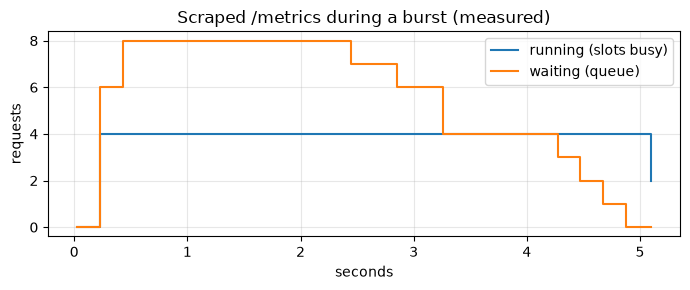

In [32]:
from prometheus_client.parser import text_string_to_metric_families


def read_metrics(base_url):
    text = httpx.get(base_url + "/metrics", timeout=5).text
    return {sample.name: sample.value for family in text_string_to_metric_families(text) for sample in family.samples}


async def poll_metrics(base_url, stop, samples, every_s=0.2):
    t0 = time.perf_counter()
    async with httpx.AsyncClient(timeout=5) as client:
        while not stop.is_set():
            text = (await client.get(base_url + "/metrics")).text
            values = {s.name: s.value for f in text_string_to_metric_families(text) for s in f.samples}
            samples.append({"t_s": time.perf_counter() - t0, "running": values.get("llamacpp:requests_processing"),
                            "waiting": values.get("llamacpp:requests_deferred")})
            await asyncio.sleep(every_s)


with LlamaServer(TARGET_F16, n_parallel=4, ctx_per_slot=1024, name="metrics") as server:
    stop_polling, metric_samples = asyncio.Event(), []
    poller = asyncio.create_task(poll_metrics(server.base, stop_polling, metric_samples))
    ops_summary, _ = await load_test(server.api, WORKLOAD[64:88], concurrency=12)
    stop_polling.set()
    await poller
    counters = read_metrics(server.base)

timeline = pd.DataFrame(metric_samples)
print(f"peak running {timeline.running.max():.0f} (= slots), peak waiting {timeline.waiting.max():.0f}; "
      f"TTFT p95 {ops_summary['ttft_p95_ms']:.0f} ms vs p50 {ops_summary['ttft_p50_ms']:.0f} ms")
print(f"from counters: {counters['llamacpp:prompt_tokens_total']:.0f} prompt tokens at "
      f"{counters['llamacpp:prompt_tokens_total'] / counters['llamacpp:prompt_seconds_total']:.0f} tok/s, "
      f"{counters['llamacpp:tokens_predicted_total']:.0f} generated tokens")
fig, ax = plt.subplots(figsize=(7, 3))
ax.step(timeline.t_s, timeline.running, where="post", label="running (slots busy)")
ax.step(timeline.t_s, timeline.waiting, where="post", label="waiting (queue)")
ax.set(xlabel="seconds", ylabel="requests", title="Scraped /metrics during a burst (measured)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
if SHARED_LLM_UP:
    try:
        shared_metrics = read_metrics(LLM_BASE_URL.removesuffix("/v1"))
        wanted = ["llamacpp:requests_processing", "llamacpp:requests_deferred", "llamacpp:prompt_tokens_total",
                  "llamacpp:tokens_predicted_total", "llamacpp:prompt_tokens_cached_total", "llamacpp:predicted_tokens_seconds"]
        for name in wanted:
            if name in shared_metrics:
                print(f"{name:40s} {shared_metrics[name]:,.1f}")
        cached, prompt = shared_metrics.get("llamacpp:prompt_tokens_cached_total"), shared_metrics.get("llamacpp:prompt_tokens_total")
        if cached is not None and prompt:
            print(f"→ share of prompt tokens served from cache on the shared server so far: {cached / (cached + prompt):.1%}")
    except (httpx.HTTPError, ValueError) as err:
        print(f"⏭️ The shared server does not expose /metrics ({type(err).__name__}); llama-server needs the --metrics flag.")
else:
    print(f"⏭️ Skipped: no LLM server at {LLM_BASE_URL}.")

llamacpp:requests_processing             4.0
llamacpp:requests_deferred               0.0
llamacpp:prompt_tokens_total             191,791.0
llamacpp:tokens_predicted_total          77,664.0
llamacpp:prompt_tokens_cached_total      306,532.0
llamacpp:predicted_tokens_seconds        27.7
→ share of prompt tokens served from cache on the shared server so far: 61.5%


### Autoscaling LLM replicas

- **Scale on the right signal:** queue depth per replica, KV-cache usage, or TTFT p95, with targets taken from your load test (the saturation knee).
- **Cold starts are slow:** a replica must pull tens to hundreds of GB of weights and load them onto GPUs, often minutes. Keep a warm minimum, pre-pull images and weights, and scale out *before* the queue explodes (use headroom, not 100% targets).
- **Scale in carefully:** drain in-flight streams first, and use cooldown windows to avoid flapping.
- **Tools:** Kubernetes HPA or KEDA on Prometheus metrics, KServe, Ray Serve autoscaling (see [Ray Serve](../10_Model_Serving/04_Ray_Serve.ipynb)), or managed endpoints.
- **Route smartly:** send a session's requests to the replica that already holds its prefix (cache-aware routing) and keep very long prompts in a separate pool.

### Self-host vs API: the break-even point

Self-hosting costs money **per hour** whether or not GPUs are busy; APIs cost money **per token**. Break-even is the daily token volume where they're equal, and it only matters if your replicas can actually **serve** that volume within the SLO. Every price below is an **EXAMPLE assumption**, not a quote. For a fuller monthly model with routing and operations costs, see the calculator in [LLM System Design](../15_Interview_Prep/04_LLM_System_Design.ipynb).

  api_usd_per_million_input    0.4
  api_usd_per_million_output   1.6
  input_share_of_tokens        0.75
  gpu_usd_per_hour             2.5
  replicas                     2
  ops_usd_per_day              0.0
  replica_tokens_per_s         2500
  target_utilization           0.6

blended API price $0.70 per million tokens | self-hosting $120 per day
break-even: 171 M tokens/day
capacity of 2 replicas at 60% utilization: 259 M tokens/day
→ self-hosting is cheaper between 171 M and 259 M tokens/day (then add replicas)


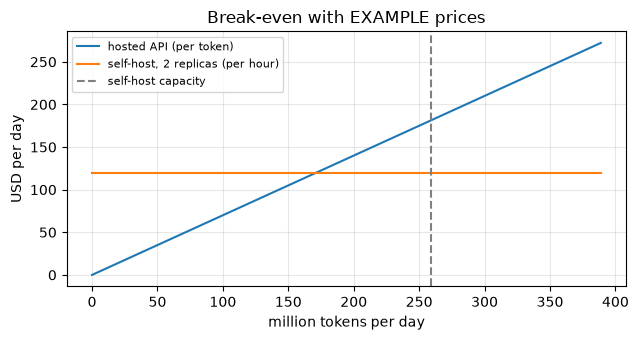

In [34]:
EXAMPLE_COSTS = dict(
    api_usd_per_million_input=0.40,        # EXAMPLE price for a small hosted model, not a quote
    api_usd_per_million_output=1.60,       # EXAMPLE
    input_share_of_tokens=0.75,            # EXAMPLE: RAG/chat traffic is input-heavy
    gpu_usd_per_hour=2.50,                 # EXAMPLE rental price for one datacenter GPU
    replicas=2,                            # at least two for redundancy
    ops_usd_per_day=0.0,                   # set to your on-call/engineering cost; it moves break-even a lot
    replica_tokens_per_s=2_500,            # MEASURE with a load test at your SLO (input + output tokens)
    target_utilization=0.6,                # you can't run at 100% and still meet latency targets
)
for key, value in EXAMPLE_COSTS.items():
    print(f"  {key:28s} {value}")

c = EXAMPLE_COSTS
api_usd_per_token = (c["input_share_of_tokens"] * c["api_usd_per_million_input"]
                     + (1 - c["input_share_of_tokens"]) * c["api_usd_per_million_output"]) / 1e6
self_host_usd_per_day = c["gpu_usd_per_hour"] * 24 * c["replicas"] + c["ops_usd_per_day"]
break_even_tokens_per_day = self_host_usd_per_day / api_usd_per_token
capacity_tokens_per_day = c["replica_tokens_per_s"] * 86_400 * c["replicas"] * c["target_utilization"]
print(f"\nblended API price ${api_usd_per_token * 1e6:.2f} per million tokens | self-hosting ${self_host_usd_per_day:,.0f} per day")
print(f"break-even: {break_even_tokens_per_day / 1e6:,.0f} M tokens/day")
print(f"capacity of {c['replicas']} replicas at {c['target_utilization']:.0%} utilization: {capacity_tokens_per_day / 1e6:,.0f} M tokens/day")
if break_even_tokens_per_day > capacity_tokens_per_day:
    print("→ these replicas can't even serve the break-even volume: the API is cheaper at any volume they can handle")
else:
    print(f"→ self-hosting is cheaper between {break_even_tokens_per_day / 1e6:,.0f} M and {capacity_tokens_per_day / 1e6:,.0f} M tokens/day (then add replicas)")

volumes = np.linspace(0, 1.5 * max(break_even_tokens_per_day, capacity_tokens_per_day), 200)
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(volumes / 1e6, volumes * api_usd_per_token, label="hosted API (per token)")
ax.plot(volumes / 1e6, np.full_like(volumes, self_host_usd_per_day), label=f"self-host, {c['replicas']} replicas (per hour)")
ax.axvline(capacity_tokens_per_day / 1e6, color="gray", ls="--", label="self-host capacity")
ax.set(xlabel="million tokens per day", ylabel="USD per day", title="Break-even with EXAMPLE prices")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The shape is the lesson: APIs win at low or spiky volume, self-hosting can win at high, steady volume, and only if an open model passes your quality bar and you count engineering time. (A previous version of this notebook claimed break-even at 5M tokens/day while its own assumptions implied about 120M. Always compute it.)

### ✍️ Your Turn

One GPU replica costs **$3.00/hour**. A hosted API costs a blended **$1.00 per million tokens**. What is the break-even volume in **tokens per day**? Store it in `break_even_per_day`.

In [35]:
break_even_per_day = None  # TODO
check("break_even_per_day", break_even_per_day, 72_000_000, hint="Daily GPU cost = 3 × 24 dollars; divide by the API price per token (1.00 / 1e6).")

⏳ break_even_per_day: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
break_even_per_day = (3.00 * 24) / (1.00 / 1e6)
check("break_even_per_day", break_even_per_day, 72_000_000)
```

72 M tokens/day is ~833 tokens/s around the clock. Then ask: can one replica serve that within the SLO, and what happens at night when traffic drops?
</details>

> 💡 **Interview angle:** "How would you autoscale an LLM service?" — scale on queue depth / KV-cache usage / TTFT p95 against targets from a load test, keep warm capacity because cold starts take minutes, use cache-aware routing, and justify self-hosting with a break-even **and** a capacity check.

## 🔧 Build It From Scratch

Two classics: a KV-cache calculator that reads a model config, proven against real caches, and a continuous-batching scheduler, driven by the timings we measured and checked against the real server.

### 1) A KV-cache memory calculator, asserted against real caches

The calculator reads a Hugging Face-style `config.json` and handles MHA/GQA, per-layer sliding windows (`layer_types`, `sliding_window_pattern`, or a global `sliding_window`), MLA latents, and any bytes-per-element (16-bit = 2, 32-bit = 4, llama.cpp `q8_0` = 34 bytes per 32 values).

One detail: Hugging Face's sliding-window cache keeps **W − 1** past tokens (the current token makes W), so the calculator takes the window convention as a parameter.

In [36]:
def attention_layout(cfg):
    """List of 'full_attention' / 'sliding_attention', one per layer."""
    n_layers = cfg["num_hidden_layers"]
    if cfg.get("layer_types"):
        return list(cfg["layer_types"])
    if cfg.get("sliding_window_pattern"):
        return ["full_attention" if (i + 1) % cfg["sliding_window_pattern"] == 0 else "sliding_attention" for i in range(n_layers)]
    if cfg.get("sliding_window") and cfg.get("use_sliding_window", True):
        return ["sliding_attention"] * n_layers
    return ["full_attention"] * n_layers


def kv_cache_bytes(config, seq_len, batch=1, bytes_per_element=2.0, window_keeps=lambda w: w):
    """KV-cache bytes for `batch` sequences of `seq_len` tokens, from a config dict."""
    cfg = config.get("text_config", config)
    if cfg.get("kv_lora_rank"):                                            # MLA: one latent vector per token per layer
        per_layer_token = (cfg["kv_lora_rank"] + cfg["qk_rope_head_dim"]) * bytes_per_element
        return int(cfg["num_hidden_layers"] * per_layer_token * seq_len * batch)
    head_dim = cfg.get("head_dim") or cfg["hidden_size"] // cfg["num_attention_heads"]
    kv_heads = cfg.get("num_key_value_heads") or cfg["num_attention_heads"]
    per_layer_token = 2 * kv_heads * head_dim * bytes_per_element
    total = 0.0
    for kind in attention_layout(cfg):
        tokens = min(seq_len, window_keeps(cfg["sliding_window"])) if kind == "sliding_attention" else seq_len
        total += per_layer_token * tokens * batch
    return int(total)


HF_WINDOW = lambda w: w - 1                                                # Hugging Face keeps W-1 past tokens

# (a) Real model, GQA: SmolLM2-135M-Instruct, batch of 2 real sequences of 100 tokens, float32 on CPU
from transformers import AutoModelForCausalLM, GptOssConfig, GptOssForCausalLM, MistralConfig, MistralForCausalLM

hf_model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct", dtype=torch.float32).eval()
tokens = torch.tensor([WIKI_IDS[:100], WIKI_IDS[100:200]])
with torch.no_grad():
    cache = hf_model(input_ids=tokens, use_cache=True).past_key_values


def measured_cache_bytes(cache):
    return sum(layer.keys.nbytes + layer.values.nbytes for layer in cache.layers)


smol_cfg = hf_model.config.to_dict()
predicted = kv_cache_bytes(smol_cfg, seq_len=100, batch=2, bytes_per_element=4)
print(f"SmolLM2-135M ({smol_cfg['num_attention_heads']} query / {smol_cfg['num_key_value_heads']} KV heads): measured {measured_cache_bytes(cache):,} bytes, calculator {predicted:,}")
assert measured_cache_bytes(cache) == predicted
del hf_model, cache
gc.collect()

# (b) Sliding window on every layer (Mistral-style), tiny randomly initialized model: 40 tokens, window 16
torch.manual_seed(0)
mistral_cfg = MistralConfig(vocab_size=1000, hidden_size=64, intermediate_size=128, num_hidden_layers=2,
                            num_attention_heads=4, num_key_value_heads=2, sliding_window=16)
with torch.no_grad():
    cache = MistralForCausalLM(mistral_cfg).eval()(input_ids=torch.randint(0, 1000, (1, 40)), use_cache=True).past_key_values
predicted = kv_cache_bytes(mistral_cfg.to_dict(), seq_len=40, bytes_per_element=4, window_keeps=HF_WINDOW)
print(f"tiny Mistral (window 16, 40 tokens): measured {measured_cache_bytes(cache):,} bytes, calculator {predicted:,}")
assert measured_cache_bytes(cache) == predicted

# (c) Alternating sliding/full layers (gpt-oss-style), tiny randomly initialized MoE model
oss_cfg = GptOssConfig(vocab_size=1000, hidden_size=64, intermediate_size=64, num_hidden_layers=4, num_attention_heads=4,
                       num_key_value_heads=2, head_dim=16, sliding_window=8, num_local_experts=4, num_experts_per_tok=2)
with torch.no_grad():
    cache = GptOssForCausalLM(oss_cfg).eval()(input_ids=torch.randint(0, 1000, (1, 40)), use_cache=True).past_key_values
predicted = kv_cache_bytes(oss_cfg.to_dict(), seq_len=40, bytes_per_element=4, window_keeps=HF_WINDOW)
print(f"tiny gpt-oss layout {oss_cfg.layer_types}: measured {measured_cache_bytes(cache):,} bytes, calculator {predicted:,}")
assert measured_cache_bytes(cache) == predicted
del cache
gc.collect()
print("✅ calculator matches Hugging Face caches for GQA, sliding-window and alternating layouts")

SmolLM2-135M (9 query / 3 KV heads): measured 9,216,000 bytes, calculator 9,216,000


tiny Mistral (window 16, 40 tokens): measured 7,680 bytes, calculator 7,680
tiny gpt-oss layout ['sliding_attention', 'full_attention', 'sliding_attention', 'full_attention']: measured 24,064 bytes, calculator 24,064


✅ calculator matches Hugging Face caches for GQA, sliding-window and alternating layouts


Now the same calculator against **llama.cpp's own allocation** for our 360M GGUF model, for a 16-bit and an 8-bit (`q8_0`) KV cache. llama.cpp prints the KV buffer size in its log when started with more verbose logging.

In [37]:
SMOL360_CONFIG = json.loads(Path(hf_hub_download("HuggingFaceTB/SmolLM2-360M-Instruct", "config.json")).read_text())
llama_cpp_checks = []
for cache_type, bytes_per_element in (("f16", 2.0), ("q8_0", 34 / 32)):
    with LlamaServer(TARGET_F16, n_parallel=2, ctx_per_slot=1024, extra=["-ctk", cache_type, "-ctv", cache_type],
                     name=f"kv_{cache_type}", verbose_log=True) as server:
        line = next(l for l in server.log().splitlines() if "llama_kv_cache: size" in l)
    match = re.search(r"size =\s*([\d.]+) MiB \(\s*(\d+) cells,\s*(\d+) layers,\s*(\d+)/(\d+) seqs\)", line)
    reported_mib, cells, seqs = float(match.group(1)), int(match.group(2)), int(match.group(5))
    predicted_mib = kv_cache_bytes(SMOL360_CONFIG, seq_len=cells, batch=seqs, bytes_per_element=bytes_per_element) / 2**20
    llama_cpp_checks.append({"cache type": cache_type, "cells per seq": cells, "seqs": seqs, "llama.cpp MiB": reported_mib, "calculator MiB": round(predicted_mib, 2)})
    assert abs(reported_mib - predicted_mib) < 0.01, (reported_mib, predicted_mib)
print(pd.DataFrame(llama_cpp_checks).to_string(index=False))
print("✅ calculator matches llama.cpp's KV buffer for 16-bit and 8-bit caches")

cache type  cells per seq  seqs  llama.cpp MiB  calculator MiB
       f16           1024     2           80.0            80.0
      q8_0           1024     2           42.5            42.5
✅ calculator matches llama.cpp's KV buffer for 16-bit and 8-bit caches


### 2) A continuous-batching scheduler simulation

A scheduler decides, at every step, which requests run. We simulate two policies on **the same request trace**:

- **Static:** when nothing is running, admit up to `max_batch` waiting requests; admit no one else until **all** of them finish (llama.cpp's `--no-cont-batching` behaves this way).
- **Continuous:** before **every** decode step, admit waiting requests into free slots.

The simulator's clock is driven by **real timings from this machine**: prefill cost per prompt token (Section 1) and decode-step time at each batch size (the slot sweep in Section 4). The trace uses real prompt and answer lengths from hh-rlhf, arriving as a Poisson process (random arrivals at a fixed average rate, seeded).

In [38]:
from collections import deque

short_prompts = phases[phases["prompt tokens"] <= 1100]
PREFILL_MS_PER_TOKEN = float((short_prompts["prefill ms (server)"] / short_prompts["prompt tokens"]).median())
batch_sizes_measured = sorted(DECODE_STEP_MS)


def step_ms(batch_size):
    return float(np.interp(batch_size, batch_sizes_measured, [DECODE_STEP_MS[b] for b in batch_sizes_measured]))


def simulate(trace, policy, max_batch):
    """Discrete-time scheduler simulation. Returns per-request TTFT/E2E (s) and the batch size of every decode step."""
    order = sorted(range(len(trace)), key=lambda i: trace[i]["arrival_s"])
    waiting, remaining, first_token, finish, steps = deque(), {}, {}, {}, []
    clock, next_arrival = 0.0, 0
    while len(finish) < len(trace):
        while next_arrival < len(order) and trace[order[next_arrival]]["arrival_s"] <= clock:
            waiting.append(order[next_arrival])
            next_arrival += 1
        active = [i for i, left in remaining.items() if left > 0]
        if policy == "continuous" or not active:                               # static admits only into an empty batch
            admitted = [waiting.popleft() for _ in range(min(len(waiting), max_batch - len(active)))]
            if admitted:
                clock += sum(trace[i]["prompt_tokens"] for i in admitted) * PREFILL_MS_PER_TOKEN / 1000
                for i in admitted:                                              # prefill produces each first token
                    first_token[i], remaining[i] = clock, trace[i]["output_tokens"] - 1
                    if remaining[i] == 0:
                        finish[i] = clock
                active = [i for i, left in remaining.items() if left > 0]
        if not active:
            if not waiting and next_arrival < len(order):
                clock = max(clock, trace[order[next_arrival]]["arrival_s"])    # idle until the next arrival
            continue
        steps.append(len(active))
        clock += step_ms(len(active)) / 1000
        for i in active:
            remaining[i] -= 1
            if remaining[i] == 0:
                finish[i] = clock
    arrivals = np.array([r["arrival_s"] for r in trace])
    ttft = np.array([first_token[i] for i in range(len(trace))]) - arrivals
    e2e = np.array([finish[i] for i in range(len(trace))]) - arrivals
    return {"ttft_s": ttft, "e2e_s": e2e, "steps": steps, "end_s": max(finish.values())}


def make_trace(workload, rate_per_s, seed=0):
    gaps = np.random.default_rng(seed).exponential(1 / rate_per_s, len(workload))
    return [{**req, "arrival_s": float(t)} for req, t in zip(workload, np.cumsum(gaps))]


MAX_BATCH = 8
capacity_req_s = slot_df.set_index("slots").loc[MAX_BATCH, "req_per_s"]
SIM_RATE = 0.6 * capacity_req_s                                                # 60% of the measured 8-slot capacity
sim_trace = make_trace(build_workload(300, seed=1), SIM_RATE, seed=1)
sim_results = {policy: simulate(sim_trace, policy, MAX_BATCH) for policy in ("static", "continuous")}

total_decode_steps = sum(r["output_tokens"] - 1 for r in sim_trace)
for policy, res in sim_results.items():
    assert sum(res["steps"]) == total_decode_steps, "every requested token must be generated exactly once"
    assert max(res["steps"]) <= MAX_BATCH
    print(f"{policy:10s}: mean TTFT {res['ttft_s'].mean():.2f}s | p95 TTFT {np.percentile(res['ttft_s'], 95):.2f}s | "
          f"mean E2E {res['e2e_s'].mean():.2f}s | mean batch {np.mean(res['steps']):.1f} | "
          f"throughput {sum(r['output_tokens'] for r in sim_trace) / res['end_s']:.0f} tok/s")
assert sim_results["continuous"]["e2e_s"].mean() < sim_results["static"]["e2e_s"].mean()
print(f"✅ invariants hold; at {SIM_RATE:.1f} req/s continuous batching cuts mean E2E latency "
      f"×{sim_results['static']['e2e_s'].mean() / sim_results['continuous']['e2e_s'].mean():.1f} on this trace")

static    : mean TTFT 1.65s | p95 TTFT 3.50s | mean E2E 2.56s | mean batch 2.9 | throughput 170 tok/s
continuous: mean TTFT 0.05s | p95 TTFT 0.09s | mean E2E 1.13s | mean batch 3.6 | throughput 174 tok/s
✅ invariants hold; at 3.5 req/s continuous batching cuts mean E2E latency ×2.3 on this trace


A simulation is only useful if it predicts reality. We **replay** the first 40 requests of the trace, with the same arrival times, against the real server under both policies, and compare with the simulator.

In [39]:
async def replay(api_base, trace):
    async with httpx.AsyncClient(timeout=600, limits=httpx.Limits(max_connections=len(trace) + 4, max_keepalive_connections=0)) as client:
        t0 = time.perf_counter()

        async def one(req):
            await asyncio.sleep(max(0.0, req["arrival_s"] - (time.perf_counter() - t0)))
            return await stream_chat(client, api_base, req["messages"], max_tokens=req["output_tokens"], ignore_eos=True)

        return pd.DataFrame(await asyncio.gather(*(one(req) for req in trace)))


replay_trace = sim_trace[:40]
validation = []
for policy, extra in (("static", ["--no-cont-batching"]), ("continuous", [])):
    with LlamaServer(TARGET_F16, n_parallel=MAX_BATCH, ctx_per_slot=1024, extra=extra, name="replay") as server:
        await load_test(server.api, WORKLOAD[-4:], concurrency=4)
        real = await replay(server.api, replay_trace)
    predicted_run = simulate(replay_trace, policy, MAX_BATCH)
    validation.append({"policy": policy, "simulator mean E2E s": predicted_run["e2e_s"].mean(), "real mean E2E s": real["e2e_s"].mean(),
                       "simulator mean TTFT s": predicted_run["ttft_s"].mean(), "real mean TTFT s": real["ttft_ms"].mean() / 1000})
validation_df = pd.DataFrame(validation)
print(validation_df.round(3).to_string(index=False))
same_winner = (validation_df.iloc[1]["real mean E2E s"] < validation_df.iloc[0]["real mean E2E s"]) == \
              (validation_df.iloc[1]["simulator mean E2E s"] < validation_df.iloc[0]["simulator mean E2E s"])
print("simulator and real server agree on which policy wins:", same_winner)

    policy  simulator mean E2E s  real mean E2E s  simulator mean TTFT s  real mean TTFT s
    static                 1.787            3.088                  1.039             1.990
continuous                 0.998            1.776                  0.045             0.272
simulator and real server agree on which policy wins: True


Absolute numbers can differ a lot. The simulator ignores HTTP overhead, prefill stalls inside running batches, and other programs sharing the GPU during the replay, and it uses median step times. It should still rank the policies the same way as the real server. That is exactly how engine teams use simulators: to explore scheduler ideas, like admission limits or chunked prefill, before touching the engine.

## ⚠️ Common Pitfalls

All pitfalls below run on one small server.

### ❌ Pitfall 1 — Measuring "TTFT" without streaming

In [40]:
pitfall_server = LlamaServer(TARGET_F16, n_parallel=2, ctx_per_slot=2048, name="pitfalls").start()
request = WORKLOAD[7]
start = time.perf_counter()
httpx.post(pitfall_server.api + "/chat/completions", timeout=120, json={
    "messages": request["messages"], "max_tokens": request["output_tokens"], "ignore_eos": True, "temperature": 0})
non_stream_ms = (time.perf_counter() - start) * 1000
print(f"❌ 'TTFT' from a non-streaming call: {non_stream_ms:.0f} ms — that's the whole response ({request['output_tokens']} tokens)")

async with httpx.AsyncClient(timeout=120) as client:
    streamed = await stream_chat(client, pitfall_server.api, request["messages"], max_tokens=request["output_tokens"], ignore_eos=True)
print(f"✅ TTFT from a streaming call     : {streamed['ttft_ms']:.0f} ms (E2E {streamed['e2e_s'] * 1000:.0f} ms)")

❌ 'TTFT' from a non-streaming call: 382 ms — that's the whole response (32 tokens)


✅ TTFT from a streaming call     : 18 ms (E2E 361 ms)


### ❌ Pitfall 2 — KV-cache math with the wrong heads or missing layers

Both bugs below appeared in real tutorials, including an earlier version of this course.

In [41]:
wrong_mb = 2048 * 32 * 128 * 2 * 2 / 1e6                              # forgot the number of KV heads
right = kv_bytes_per_token(n_layers=32, n_kv_heads=32, head_dim=128) * 2048
print(f"❌ Llama-2-7B, 2,048 tokens, formula without KV heads: {wrong_mb:.1f} MB")
print(f"✅ with all terms: {right / 2**30:.2f} GiB  ({right / (wrong_mb * 1e6):.0f}× more)")

wrong_per_token = kv_bytes_per_token(80, 64, 128)                    # used query heads for Llama-2-70B
right_per_token = kv_bytes_per_token(80, 8, 128)                     # GQA: 8 KV heads
print(f"❌ Llama-2-70B with 64 'KV heads': {wrong_per_token / 2**20:.2f} MiB/token")
print(f"✅ with its real 8 KV heads   : {right_per_token / 2**20:.2f} MiB/token")

gpu_gib, weights_gib = 80, 6.74e9 * 2 / 2**30                        # Llama-2-7B bf16 weights on an 80 GiB GPU (EXAMPLE budget: 90% usable)
budget = gpu_gib * 0.9 - weights_gib
print(f"❌ 'kv_size_per_token_mb = 0.033' → {budget * 1024 / (0.033 * 2048):,.0f} concurrent 2K-token requests")
print(f"✅ real 0.5 MiB/token → {budget * 2**30 // right:.0f} concurrent 2K-token requests")

❌ Llama-2-7B, 2,048 tokens, formula without KV heads: 33.6 MB
✅ with all terms: 1.00 GiB  (32× more)
❌ Llama-2-70B with 64 'KV heads': 2.50 MiB/token
✅ with its real 8 KV heads   : 0.31 MiB/token
❌ 'kv_size_per_token_mb = 0.033' → 901 concurrent 2K-token requests
✅ real 0.5 MiB/token → 59 concurrent 2K-token requests


### ❌ Pitfall 3 — Reporting the mean and hiding the tail

In [42]:
static_run = batching_requests["8 slots, static"]
print(f"❌ 'average TTFT is {static_run.ttft_ms.mean():.0f} ms' (static batching run from Section 4)")
print(f"✅ p50 {static_run.ttft_ms.median():.0f} ms | p95 {np.percentile(static_run.ttft_ms, 95):.0f} ms | "
      f"p99 {np.percentile(static_run.ttft_ms, 99):.0f} ms | max {static_run.ttft_ms.max():.0f} ms — users in the tail waited "
      f"{static_run.ttft_ms.max() / static_run.ttft_ms.median():.0f}× the median")

❌ 'average TTFT is 3098 ms' (static batching run from Section 4)
✅ p50 2696 ms | p95 6888 ms | p99 6888 ms | max 6888 ms — users in the tail waited 3× the median


### ❌ Pitfall 4 — Putting a timestamp or request ID at the *start* of the prompt

In [43]:
policy_text = TOKENIZER.decode(WIKI_IDS[30_000:30_800])


async def cached_share(system_prompt_fn):
    shares = []
    async with httpx.AsyncClient(timeout=120) as client:
        for i in range(3):
            messages = [{"role": "system", "content": system_prompt_fn(i)}, {"role": "user", "content": f"Question {i}: summarize."}]
            r = await stream_chat(client, pitfall_server.api, messages, max_tokens=4)
            shares.append(r["cached_tokens"] / r["prompt_tokens"])
    return shares[1:]                                                  # the first request only fills the cache


bad = await cached_share(lambda i: f"Request id {1000 + i} at {time.time():.3f}.\n" + policy_text)
good = await cached_share(lambda i: policy_text + f"\nRequest id {1000 + i} at {time.time():.3f}.")
print(f"❌ variable text first: {np.mean(bad):.0%} of prompt tokens served from cache")
print(f"✅ variable text last : {np.mean(good):.0%} of prompt tokens served from cache")

❌ variable text first: 1% of prompt tokens served from cache
✅ variable text last : 96% of prompt tokens served from cache


### ❌ Pitfall 5 — Forgetting that `-c` is shared by all slots in llama.cpp

In [44]:
slot_ctx = httpx.get(pitfall_server.base + "/slots").json()[0]["n_ctx"]
print(f"server started with -np 2 -c {2 * 2048}: each slot gets n_ctx = {slot_ctx}")
long_prompt = TOKENIZER.decode(WIKI_IDS[40_000:42_500])
response = httpx.post(pitfall_server.api + "/chat/completions", timeout=120,
                      json={"messages": [{"role": "user", "content": long_prompt}], "max_tokens": 8})
print(f"❌ a 2,500-token prompt: HTTP {response.status_code} → {response.json()['error']['message']}")
fits = httpx.post(pitfall_server.api + "/chat/completions", timeout=120,
                  json={"messages": [{"role": "user", "content": TOKENIZER.decode(WIKI_IDS[40_000:41_500])}], "max_tokens": 8})
print(f"✅ size -c as slots × longest request (or send shorter prompts): a 1,500-token prompt → HTTP {fits.status_code}")
pitfall_server.stop()

server started with -np 2 -c 4096: each slot gets n_ctx = 2048
❌ a 2,500-token prompt: HTTP 400 → request (2530 tokens) exceeds the available context size (2048 tokens), try increasing it


✅ size -c as slots × longest request (or send shorter prompts): a 1,500-token prompt → HTTP 200


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — KV cache for a batch
Llama-3.1-8B has 32 layers, 8 KV heads and head_dim 128. How many **GiB** of 16-bit KV cache do **4 sequences of 32,768 tokens** need? Store it in `kv_gib`.

In [45]:
kv_gib = None  # TODO
check("kv_gib", kv_gib, 16.0, hint="bytes per token = 2 × 32 × 8 × 128 × 2; multiply by tokens and batch; divide by 2**30.")

⏳ kv_gib: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
kv_gib = kv_bytes_per_token(32, 8, 128, 2) * 32_768 * 4 / 2**30
check("kv_gib", kv_gib, 16.0)
```
128 KiB per token × 131,072 tokens = 16 GiB, the same as the model's own bf16 weights.
</details>

### 🟢 Exercise 2 — Slots and context
You start `llama-server -c 16384 -np 8`. Store a dict `slot_answer = {"per_slot": ..., "fits": ...}`: the context per slot, and whether a request with a **1,900-token prompt** and `max_tokens=256` can finish without hitting the limit (`True`/`False`).

In [46]:
slot_answer = None  # TODO
check("slot_answer", slot_answer, {"per_slot": 2048, "fits": False}, hint="16384 / 8 per slot; prompt + max output must fit in it.")

⏳ slot_answer: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
per_slot = 16384 // 8
slot_answer = {"per_slot": per_slot, "fits": 1900 + 256 <= per_slot}
check("slot_answer", slot_answer, {"per_slot": 2048, "fits": False})
```
2,156 tokens don't fit in 2,048. The generation would stop early (or context shifting would drop old tokens).
</details>

### 🟢 Exercise 3 — How big is the GGUF?
An 8.03B-parameter model is quantized to Q4_K_M, which averages **4.89 bits per weight** for this model. Estimate its size in **GiB** and store it in `gguf_gib`.

In [47]:
gguf_gib = None  # TODO
check("gguf_gib", gguf_gib, 4.5714, hint="params × bits / 8 bytes, then / 2**30.")

⏳ gguf_gib: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
gguf_gib = 8.03e9 * 4.89 / 8 / 2**30
check("gguf_gib", gguf_gib, 4.5714)
```
</details>

### 🟡 Exercise 4 — Goodput from a load test
Ten requests finished in a **5-second** window. Their TTFT and TPOT values are below. With an SLO of **TTFT ≤ 500 ms and TPOT ≤ 50 ms**, compute **goodput in requests per second**. Store it in `goodput_rps`.

In [48]:
ttft_ms_obs = np.array([120, 340, 480, 510, 90, 700, 260, 450, 300, 1200])
tpot_ms_obs = np.array([35, 42, 55, 30, 48, 20, 49, 51, 38, 25])
goodput_rps = None  # TODO
check("goodput_rps", goodput_rps, 1.0, hint="Count requests meeting BOTH conditions, divide by the window length.")

⏳ goodput_rps: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ttft_ms_obs = np.array([120, 340, 480, 510, 90, 700, 260, 450, 300, 1200])
tpot_ms_obs = np.array([35, 42, 55, 30, 48, 20, 49, 51, 38, 25])
goodput_rps = ((ttft_ms_obs <= 500) & (tpot_ms_obs <= 50)).sum() / 5
check("goodput_rps", goodput_rps, 1.0)
```
Throughput is 2 requests/s, but only 5 of the 10 met the SLO, so goodput is 1 request/s.
</details>

### 🟡 Exercise 5 — Speculative decoding speedup
A drafter proposes **γ = 4** tokens, each accepted with probability **α = 0.8**, and costs **c = 0.1** of a target forward pass. Use the formula from Section 7 to compute the expected speedup. Store it in `spec_speedup`.

In [49]:
spec_speedup = None  # TODO
check("spec_speedup", spec_speedup, 2.4011, hint="(1 − α^(γ+1)) / ((1 − α)(γc + 1)).")

⏳ spec_speedup: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
alpha, gamma, c = 0.8, 4, 0.1
spec_speedup = (1 - alpha ** (gamma + 1)) / ((1 - alpha) * (gamma * c + 1))
check("spec_speedup", spec_speedup, 2.4011)
```
3.36 tokens per target pass, divided by a 1.4× cost per round. Halving c to 0.05 would give ×2.8.
</details>

### 🔴 Exercise 6 — Paged KV blocks with a shared prefix (interview-style)
Many requests share one system prompt of `prefix_tokens`, followed by different suffixes (`suffix_tokens`, one per request). With paging and prefix caching, **full** blocks of the shared prefix are stored once; everything else (the partial last prefix block and each suffix) is per request. Implement `blocks_needed(prefix_tokens, suffix_tokens, block_size)` returning the **total number of physical blocks**.

In [50]:
def blocks_needed(prefix_tokens, suffix_tokens, block_size):
    return None  # TODO


cases = [(100, [20, 5, 60], 16), (64, [1, 1], 16), (10, [10, 30], 16), (0, [16, 17], 16)]
results = [blocks_needed(*case) for case in cases]
check("blocks_needed", None if results[0] is None else results, [13, 6, 5, 3],
      hint="shared = prefix // block_size; each request needs ceil((prefix + suffix) / block_size) − shared of its own.")

⏳ blocks_needed: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def blocks_needed(prefix_tokens, suffix_tokens, block_size):
    shared = prefix_tokens // block_size                        # only FULL blocks can be shared
    own = sum(math.ceil((prefix_tokens + s) / block_size) - shared for s in suffix_tokens)
    return shared + own


cases = [(100, [20, 5, 60], 16), (64, [1, 1], 16), (10, [10, 30], 16), (0, [16, 17], 16)]
check("blocks_needed", [blocks_needed(*case) for case in cases], [13, 6, 5, 3])
```

For the first case, without sharing the three requests need 8 + 7 + 10 = 25 blocks; with sharing, 13. vLLM hashes each full block together with all tokens before it, so identical prefixes map to the same physical blocks. The partial block isn't shared because the next token written into it differs per request.
</details>

## 🚀 Mini Project: Load-Test and Capacity-Plan Your Own LLM Server

**Goal:** decide how to serve SmolLM2-360M for a (pretend) internal help-desk assistant. Load-test **three quantizations** across **five concurrency levels** with real conversations, find the **saturation knee**, check an **SLO**, and produce a computed **capacity plan and recommendation**.

**Steps:** fix the workload and SLO → sweep quantization × concurrency → plot the curves → find the knee and SLO capacity → combine with quality from Section 6 → capacity plan and recommendation.

### Step 1 — Workload, SLO and traffic assumptions

The workload comes from real hh-rlhf conversations: prompts up to 400 tokens, answers forced to their reference length (8–128 tokens). The SLO and traffic are **EXAMPLE** targets sized for a tiny model on a laptop.

In [51]:
MP_QUANTS = ["F16", "Q8_0", "Q4_K_M"]                       # Q2_K is excluded up front: its perplexity is far worse (Section 6)
MP_CONCURRENCY = [1, 4, 8, 16, 32]
MP_SLOTS, MP_CTX = 16, 1024
MP_SLO = {"ttft_p95_ms": 1000, "tpot_p95_ms": 50}            # EXAMPLE SLO: first token within 1 s, ≥ 20 tokens/s per user
MP_TRAFFIC = {"peak_requests_per_s": 20, "headroom": 0.7}    # EXAMPLE peak load; run replicas at ≤70% of measured capacity
print("SLO:", MP_SLO, "| traffic:", MP_TRAFFIC)
print(f"server: {MP_SLOTS} slots × {MP_CTX} tokens; workload mean prompt {lengths.prompt_tokens.mean():.0f} tokens, mean answer {lengths.output_tokens.mean():.0f} tokens")

SLO: {'ttft_p95_ms': 1000, 'tpot_p95_ms': 50} | traffic: {'peak_requests_per_s': 20, 'headroom': 0.7}
server: 16 slots × 1024 tokens; workload mean prompt 150 tokens, mean answer 54 tokens


### Step 2 — Sweep quantization × concurrency

One server at a time, each warmed up first. At concurrency *c* we send `max(16, 2c)` requests, so every level has enough samples for a p95. Concurrency above 16 exceeds the slots, so requests start to **queue**.

In [52]:
mp_rows, mp_requests = [], {}
sweep_start = time.perf_counter()
for quant in MP_QUANTS:
    with LlamaServer(QUANT_FILES[quant], n_parallel=MP_SLOTS, ctx_per_slot=MP_CTX, name=f"loadtest_{quant}") as server:
        await load_test(server.api, WORKLOAD[-8:], concurrency=8)                      # warm-up
        for conc in MP_CONCURRENCY:
            summary, per_request = await load_test(server.api, WORKLOAD[:max(16, 2 * conc)], concurrency=conc)
            per_request["meets_slo"] = (per_request.ttft_ms <= MP_SLO["ttft_p95_ms"]) & (per_request.tpot_ms <= MP_SLO["tpot_p95_ms"])
            summary["goodput_req_per_s"] = per_request["meets_slo"].sum() / summary["wall_s"]
            mp_rows.append({"quant": quant, **summary})
            mp_requests[(quant, conc)] = per_request
mp = pd.DataFrame(mp_rows)
print(f"sweep took {time.perf_counter() - sweep_start:.0f} s")
print(mp[["quant", "concurrency", "requests", "output_tok_per_s", "req_per_s", "goodput_req_per_s",
          "ttft_p50_ms", "ttft_p95_ms", "tpot_p50_ms", "tpot_p95_ms"]].round(1).to_string(index=False))

sweep took 213 s
 quant  concurrency  requests  output_tok_per_s  req_per_s  goodput_req_per_s  ttft_p50_ms  ttft_p95_ms  tpot_p50_ms  tpot_p95_ms
   F16            1        16              52.9        1.0                0.9         72.2        201.6          8.0         30.1
   F16            4        16              26.9        0.5                0.1        240.6       2860.8         52.6        152.9
   F16            8        16             111.7        2.1                0.4        456.1        528.3         59.7         77.1
   F16           16        32             198.5        3.4                1.7       1973.5       3763.4         34.5         41.7
   F16           32        64             282.5        4.8                1.2       2269.3       3699.9         42.8         56.7
  Q8_0            1        16              64.8        1.2                1.1         37.3        139.2          7.7         27.5
  Q8_0            4        16             113.0        2.1               

### Step 3 — Plot the curves

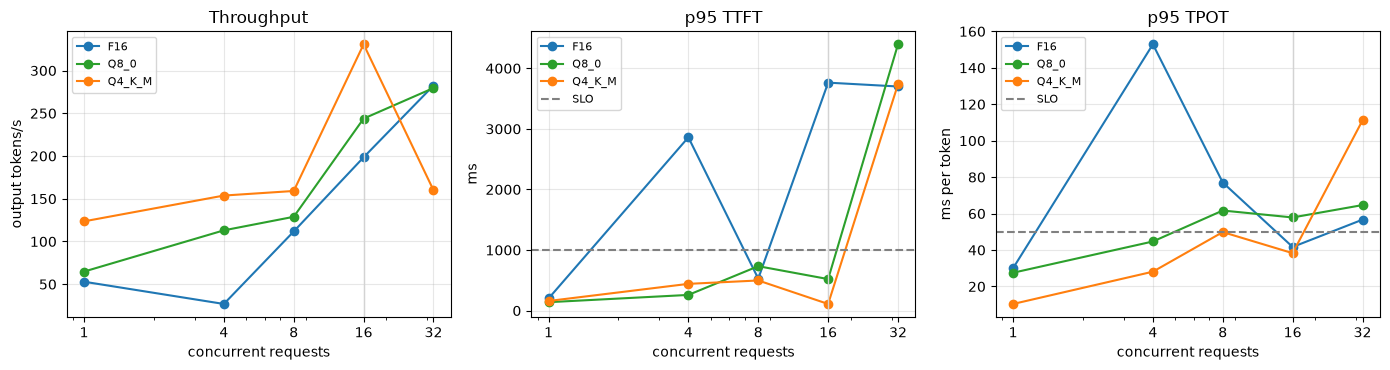

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for quant, color in zip(MP_QUANTS, ["tab:blue", "tab:green", "tab:orange"]):
    sub = mp[mp.quant == quant]
    axes[0].plot(sub.concurrency, sub.output_tok_per_s, marker="o", color=color, label=quant)
    axes[1].plot(sub.concurrency, sub.ttft_p95_ms, marker="o", color=color, label=quant)
    axes[2].plot(sub.concurrency, sub.tpot_p95_ms, marker="o", color=color, label=quant)
axes[1].axhline(MP_SLO["ttft_p95_ms"], ls="--", color="gray", label="SLO")
axes[2].axhline(MP_SLO["tpot_p95_ms"], ls="--", color="gray", label="SLO")
for ax, title, ylabel in zip(axes, ["Throughput", "p95 TTFT", "p95 TPOT"], ["output tokens/s", "ms", "ms per token"]):
    ax.set(xscale="log", xticks=MP_CONCURRENCY, xticklabels=MP_CONCURRENCY, xlabel="concurrent requests", ylabel=ylabel, title=title)
    ax.axvline(MP_SLOTS, color="lightgray", lw=1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Step 4 — Find the saturation knee and the SLO capacity

- **Knee:** the last concurrency before p95 TTFT jumps past 5× its single-request value. Beyond it, requests queue for a free slot, and you buy latency without much extra throughput.
- **SLO capacity:** the measured concurrency with the highest goodput whose p95 TTFT and p95 TPOT both meet the SLO.

In [54]:
def knee_concurrency(sub, factor=5):
    """Last concurrency before p95 TTFT exceeds `factor` × its single-request value (requests start queueing)."""
    sub = sub.sort_values("concurrency").reset_index(drop=True)
    over = sub.index[sub["ttft_p95_ms"] > factor * sub.loc[0, "ttft_p95_ms"]]
    return int(sub.loc[over[0] - 1, "concurrency"]) if len(over) and over[0] > 0 else int(sub["concurrency"].iloc[-1])


plan_rows = []
for quant in MP_QUANTS:
    sub = mp[mp.quant == quant]
    ok = sub[(sub.ttft_p95_ms <= MP_SLO["ttft_p95_ms"]) & (sub.tpot_p95_ms <= MP_SLO["tpot_p95_ms"])]
    best = ok.sort_values("goodput_req_per_s").iloc[-1] if len(ok) else None
    plan_rows.append({"quant": quant, "knee concurrency": knee_concurrency(sub),
                      "max tok/s": sub.output_tok_per_s.max(),
                      "SLO concurrency": int(best.concurrency) if best is not None else 0,
                      "SLO goodput req/s": float(best.goodput_req_per_s) if best is not None else 0.0,
                      "Δ perplexity %": quant_table.loc[quant, "Δ perplexity %"],
                      "weights MiB": quant_table.loc[quant, "size MiB"]})
plan = pd.DataFrame(plan_rows).set_index("quant")
print(plan.round(2).to_string())

        knee concurrency  max tok/s  SLO concurrency  SLO goodput req/s  Δ perplexity %  weights MiB
quant                                                                                               
F16                    1     282.45                1               0.93            0.00       690.24
Q8_0                   4     279.57                4               1.99            0.07       366.80
Q4_K_M                16     330.70               16               5.69            2.14       256.35


### Step 5 — Capacity plan and recommendation

Replicas = ceil(peak load ÷ (SLO goodput per replica × headroom)). Memory per replica = weights + KV cache for all slots (our calculator from Build It). The recommendation is **computed**: among formats within 5% of FP16 perplexity, pick the one needing the fewest replicas, breaking ties by the smaller memory footprint.

In [55]:
kv_per_replica_mib = kv_cache_bytes(SMOL360_CONFIG, seq_len=MP_CTX, batch=MP_SLOTS, bytes_per_element=2) / 2**20
plan["replicas needed"] = [math.ceil(MP_TRAFFIC["peak_requests_per_s"] / (g * MP_TRAFFIC["headroom"])) if g > 0 else np.nan
                           for g in plan["SLO goodput req/s"]]
plan["memory per replica MiB"] = plan["weights MiB"] + kv_per_replica_mib
plan["total memory MiB"] = plan["replicas needed"] * plan["memory per replica MiB"]
print(f"KV cache per replica ({MP_SLOTS} slots × {MP_CTX} tokens, 16-bit): {kv_per_replica_mib:.0f} MiB")
print(plan[["SLO goodput req/s", "replicas needed", "memory per replica MiB", "total memory MiB", "Δ perplexity %"]].round(1).to_string())

eligible = plan[(plan["Δ perplexity %"] <= 5) & plan["replicas needed"].notna()]
if len(eligible):
    choice = eligible.sort_values(["replicas needed", "memory per replica MiB"]).index[0]
    row = plan.loc[choice]
    print(f"\n✅ Recommendation: {choice} — {int(row['replicas needed'])} replica(s) of {MP_SLOTS} slots for {MP_TRAFFIC['peak_requests_per_s']} req/s at p95 "
          f"TTFT ≤ {MP_SLO['ttft_p95_ms']} ms and TPOT ≤ {MP_SLO['tpot_p95_ms']} ms; perplexity {row['Δ perplexity %']:+.1f}% vs FP16; "
          f"{row['memory per replica MiB']:.0f} MiB per replica.")
    runner_up = plan.drop(index=choice)["replicas needed"].min()
    print(f"   Knee on this machine: ~{int(row['knee concurrency'])} concurrent requests; beyond it, add replicas instead of slots. "
          f"Next-best option needs {runner_up:.0f} replica(s).")
else:
    print("\n⚠️ No format met the SLO at any tested concurrency within the quality gate: relax the SLO, use faster hardware, or add replicas per level.")

KV cache per replica (16 slots × 1024 tokens, 16-bit): 640 MiB
        SLO goodput req/s  replicas needed  memory per replica MiB  total memory MiB  Δ perplexity %
quant                                                                                               
F16                   0.9               31                  1330.2           41237.4             0.0
Q8_0                  2.0               15                  1006.8           15102.0             0.1
Q4_K_M                5.7                6                   896.4            5378.1             2.1

✅ Recommendation: Q4_K_M — 6 replica(s) of 16 slots for 20 req/s at p95 TTFT ≤ 1000 ms and TPOT ≤ 50 ms; perplexity +2.1% vs FP16; 896 MiB per replica.
   Knee on this machine: ~16 concurrent requests; beyond it, add replicas instead of slots. Next-best option needs 15 replica(s).


**Stretch goals**
1. Add **Q2_K** and a **q8_0 KV cache** (`-ctk q8_0 -ctv q8_0`) to the sweep. Does KV quantization change TPOT at high concurrency?
2. Replace fixed concurrency with **open-loop Poisson arrivals** at several request rates (reuse `make_trace` and `replay`). Where does TTFT blow up?
3. Measure the effect of `--no-cont-batching` and of different `-ub` (ubatch) sizes on p95 ITL when long prompts arrive during decoding.
4. Run the same workload with `vllm bench serve` against `vllm serve` on a Colab GPU and compare the curve shapes.
5. Turn the plan into **cost**: add an EXAMPLE $/hour per replica and compute $ per million output tokens at the SLO operating point.

### 🗣️ How to talk about this in an interview
- "I load-tested my own llama.cpp server with **real conversation lengths** from hh-rlhf, streaming every request to measure TTFT, TPOT and E2E per request, across 3 quantizations × 5 concurrency levels."
- "I report **p95 and goodput under an SLO**, not averages. Once concurrency exceeded the server's slots, requests queued and p95 TTFT jumped several-fold. That saturation knee is where I'd set the autoscaling target."
- "Quantization was a **quality-gated** decision: I measured perplexity for each format and excluded anything more than 5% worse than FP16 before comparing capacity."
- "The capacity plan is computed: replicas = peak load ÷ (SLO goodput × headroom), plus memory per replica = weights + KV cache from a calculator I verified against llama.cpp's real allocation."
- "Next I'd validate with open-loop arrivals, add prefix-heavy traffic, and repeat on the production GPU and engine, because the numbers change but the method doesn't."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What's the difference between prefill and decode, and why do they have different bottlenecks?**

<details><summary>Show answer</summary>

- **30-second answer:** Prefill runs all prompt tokens through the model in one parallel pass and builds the KV cache; it is compute-bound and determines TTFT. Decode generates one token per pass, reading all weights and the growing KV cache each time; it is memory-bandwidth-bound and determines TPOT.
- **Go deeper:** That's why long prompts hurt TTFT (fix: prefix caching, chunked prefill), long outputs hurt E2E (fix: batching, quantization, speculative decoding), and why some systems disaggregate prefill and decode onto different GPUs. In Section 1, prefill processed tokens much faster than decode produced them on the same hardware.
- **❌ Common wrong answer:** "Every token costs the same amount of time whether it's input or output."

</details>

**Q2. Define TTFT, TPOT, throughput and goodput. Why report percentiles?**

<details><summary>Show answer</summary>

- **30-second answer:** TTFT = time to first token; TPOT = average time per subsequent token; throughput = tokens (or requests) per second across all users; goodput = requests per second that meet the SLO. Latency is long-tailed and users remember the slow requests, so SLOs use p95/p99, not means.
- **Go deeper:** TTFT includes queueing, so it is the first metric to degrade under overload. ITL spikes reveal long prefills stalling decodes. Measure from the client with streaming, and check that server-side metrics agree.
- **❌ Common wrong answer:** "Throughput is the key metric; higher tokens/s is always better." Doubling throughput by overloading can halve goodput.

</details>

**Q3. Size the KV cache of Llama-3.1-8B for 16 concurrent 8K-token requests.**

<details><summary>Show answer</summary>

- **30-second answer:** 2 × 32 layers × 8 KV heads × 128 head_dim × 2 bytes = 131,072 bytes (128 KiB) per token. × 8,192 tokens × 16 sequences = **16 GiB** in bf16, about the same as the weights. An FP8 KV cache halves it.
- **Go deeper:** Use **KV heads** (GQA), not attention heads. Sliding-window layers cap at the window; MLA stores a small latent; MoE doesn't change it. Engines reserve KV memory in blocks, so capacity = (GPU memory × utilization − weights − activations) ÷ bytes per token.
- **❌ Common wrong answer:** Using 32 attention heads (4× too big), forgetting the ×2 for K and V, or forgetting the layers.

</details>

**Q4. How do GQA, sliding-window attention, MLA and MoE affect inference memory?**

<details><summary>Show answer</summary>

- **30-second answer:** GQA shares KV heads across query heads, shrinking the cache by the grouping factor. Sliding-window layers store at most W tokens. MLA (DeepSeek) caches a compressed latent per layer instead of full K/V. MoE increases total **weight** memory (all experts must be loaded) but not the KV cache, and reduces compute per token.
- **Go deeper:** Real models mix them: Gemma 3 uses 5 local layers per global layer; gpt-oss alternates 128-token windows with full attention and is MoE; DeepSeek-V3 is MLA + MoE. MoE serving adds expert parallelism and routing-imbalance concerns.
- **❌ Common wrong answer:** "MoE models are cheap to serve because only 2 experts are active." Every expert still has to sit in memory.

</details>

**Q5. Explain continuous batching and chunked prefill.**

<details><summary>Show answer</summary>

- **30-second answer:** Continuous batching schedules per decode step: finished sequences leave and waiting ones join immediately, so slots never idle waiting for the longest request. Chunked prefill splits long prompts into pieces mixed with decode steps so a big prompt doesn't freeze everyone's token stream.
- **Go deeper:** Static batching wastes slots in proportion to the spread of output lengths (the Section 4 exercise: ~60% for a realistic batch). Schedulers also enforce a token budget per step (vLLM `max_num_batched_tokens`), a max number of sequences, and preemption when KV memory runs out.
- **❌ Common wrong answer:** "Wait 50 ms, collect requests, run them as a batch." That's dynamic batching for fixed-size models, not iteration-level scheduling.

</details>

**Q6. What problem does PagedAttention solve, and how does prefix caching build on it?**

<details><summary>Show answer</summary>

- **30-second answer:** Contiguous per-request KV reservations sized for the maximum length waste most GPU memory. PagedAttention stores the cache in fixed-size blocks mapped through a block table, allocated on demand, so waste is under one block per sequence and blocks can be shared. Prefix caching shares the blocks of identical prompt prefixes (vLLM hashes each full block with its prefix; SGLang uses a radix tree), skipping their prefill.
- **Go deeper:** Prompt design matters: static content first, variable content last. Cache-aware routing sends related requests to the same replica. Monitor the prefix-cache hit rate.
- **❌ Common wrong answer:** "PagedAttention makes attention math faster." It is mainly a memory-management technique (plus kernels that read non-contiguous blocks).

</details>

**Q7. Compare GPTQ, AWQ, FP8 and GGUF k-quants. Which speed up prefill and which speed up decode?**

<details><summary>Show answer</summary>

- **30-second answer:** GPTQ and AWQ are 4-bit weight-only post-training methods with calibration (GPTQ uses second-order error correction; AWQ protects salient channels found from activations). GGUF k-quants are llama.cpp block formats for CPUs/Macs/GPUs. FP8 quantizes weights **and** activations on supporting GPUs. Weight-only formats mainly speed decode (fewer bytes to move); FP8/W8A8 can also speed prefill.
- **Go deeper:** Always evaluate against the 16-bit baseline: perplexity or KL divergence first, then task evals and sensitive slices. Small models suffer more at low bits. KV-cache quantization is a separate knob.
- **❌ Common wrong answer:** "4-bit is always 4× faster than 16-bit." Dequantization costs compute, prefill may not speed up, and quality can drop.

</details>

**Q8. How does speculative decoding work, is it lossless, and when doesn't it help?**

<details><summary>Show answer</summary>

- **30-second answer:** A cheap drafter proposes γ tokens; the target verifies them in one forward pass; accepted tokens are kept and the first rejection is replaced by the target's token. With rejection sampling the output distribution equals the target's, so it is lossless. Speedup ≈ (1 − α^(γ+1)) / ((1 − α)(γc + 1)).
- **Go deeper:** It fails when acceptance α is low (creative text, high temperature, mismatched drafter), when the drafter isn't much cheaper or verification and bookkeeping overhead dominate (as with tiny models on a laptop in Section 7), or at high batch sizes where the GPU is already compute-saturated. Variants: n-gram/prompt lookup, Medusa, EAGLE, MTP heads.
- **❌ Common wrong answer:** "It approximates the big model with the small one, so quality drops a bit."

</details>

**Q9. How do structured outputs guarantee valid JSON?**

<details><summary>Show answer</summary>

- **30-second answer:** The JSON schema, regex or grammar is compiled into a state machine; at every step the engine masks out tokens that can't continue a valid string, so sampling can only pick valid tokens (XGrammar, Outlines, llguidance, llama.cpp GBNF).
- **Go deeper:** Format ≠ correctness: evaluate content separately. Handle truncation (`finish_reason == "length"`). Forcing an answer too early can reduce quality, so allow reasoning first. Grammar compilation can add latency the first time a schema is seen.
- **❌ Common wrong answer:** "It retries until the JSON parses."

</details>

### 💻 Coding

**Q10. Write a function that estimates how many concurrent sequences fit on a GPU.**

<details><summary>Show answer</summary>

- **30-second answer:** `kv_budget = gpu_bytes * utilization - weight_bytes - overhead_bytes; per_token = 2 * layers * kv_heads * head_dim * bytes_per_elem; return int(kv_budget // (per_token * avg_tokens_per_seq))`. For Llama-3.1-8B bf16 on 80 GiB at 90% with ~2 GiB overhead: ≈ 55 GiB / 128 KiB ≈ 450K tokens → ~110 sequences of 4K tokens.
- **Go deeper:** Use the *average* live length for paged engines, not the maximum; add sliding-window and MLA handling (see Build It); verify against the engine's reported KV capacity at startup (vLLM logs the number of KV blocks; llama.cpp logs the KV buffer).
- **❌ Common wrong answer:** Dividing total GPU memory by per-token KV without subtracting the weights.

</details>

**Q11. Given the arrival times of streamed chunks for many requests, compute p95 TTFT, mean TPOT and goodput.**

<details><summary>Show answer</summary>

- **30-second answer:** Per request: `ttft = t[0]`, `tpot = (t[-1] - t[0]) / (n_tokens - 1)`, `meets = ttft <= T and tpot <= P`. Across requests: `np.percentile(ttfts, 95)`, `np.mean(tpots)`, `meets.sum() / window_seconds`.
- **Go deeper:** Use the server's token count (`usage.completion_tokens`), because one chunk may hold several tokens (speculative decoding). Measure from when the request was *sent* and include client-side queueing if that is what users feel. Exclude warm-up requests.
- **❌ Common wrong answer:** Computing TPOT as E2E / n_tokens, which mixes prefill into the per-token number.

</details>

### 🐛 Debugging Scenarios

**Q12. At peak traffic, p95 TTFT jumps from 300 ms to 8 s but TPOT barely changes. What's happening and what do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Requests are **queueing**: running slots or KV memory are full, so new requests wait before prefill. Confirm with `num_requests_waiting` / `requests_deferred` and KV-cache usage. Fix: add replicas or scale earlier (queue-based autoscaling), cap max context or route long prompts to a separate pool, improve prefix-cache hit rates, and apply admission control with clear errors instead of silent waits.
- **Go deeper:** If TTFT spikes correlate with a few very long prompts, enable or tune chunked prefill. If preemptions rise, the KV cache is over-committed: lower `max_num_seqs` or use an FP8 KV cache.
- **❌ Common wrong answer:** "The model got slower; switch to a smaller model." TPOT would have moved if compute were the issue.

</details>

**Q13. After switching from FP16 to INT4, overall evals look fine but users report worse answers on code and in Spanish. How do you investigate?**

<details><summary>Show answer</summary>

- **30-second answer:** Evaluate **per slice** against the FP16 baseline: code tests, Spanish tasks, perplexity/KL divergence on in-domain text. Low-bit quantization often hurts rarer skills and languages first. Fixes: recalibrate AWQ/GPTQ with in-domain data, use a higher-precision mix (Q5/Q6_K, Q4_K_M instead of Q4_0), keep sensitive layers in higher precision, or use FP8.
- **Go deeper:** Add these slices to the release gate, so the next format change can't regress silently. Compare latency and cost gains against the quality loss explicitly.
- **❌ Common wrong answer:** "Average accuracy only dropped 0.5%, so it's fine."

</details>

**Q14. A vLLM deployment logs preemption warnings and latency spikes when many long conversations are active. What knobs do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** The KV cache is running out, so the scheduler evicts sequences and recomputes them later. Check KV usage; reduce `--max-num-seqs` or `--max-model-len`; raise `--gpu-memory-utilization` if safe; use `--kv-cache-dtype fp8`; add tensor parallelism or more replicas; trim conversation history or summarize it.
- **Go deeper:** Separate long-context traffic into its own pool. Watch `vllm:num_preemptions` and `vllm:kv_cache_usage_perc` on dashboards, with alerts before 100%.
- **❌ Common wrong answer:** "Increase `max_num_seqs` to process the backlog faster." That makes KV pressure worse.

</details>

### 🏗️ Design

**Q15. Design serving for an internal chatbot: 50 requests/s at peak, 2K-token prompts with a shared 1.5K-token system prompt, 300-token answers, p95 TTFT ≤ 1 s. Self-host or API?**

<details><summary>Show answer</summary>

- **30-second answer:** First pick the smallest model that passes the quality bar. Estimate tokens: 50 × (2,000 + 300) = 115K tokens/s at peak, ~100K–150K input-heavy tokens/s. Compute API cost per day vs GPU replicas: the replica count comes from a **load test** at the SLO (goodput per replica ÷ headroom). With a shared 1.5K prefix, prefix caching removes ~75% of prefill, so use vLLM/SGLang with cache-aware routing. Self-host only if the break-even and capacity checks both favour it and data or latency control matters.
- **Go deeper:** Mention redundancy (≥2 replicas, multiple zones), queue-based autoscaling with warm capacity, FP8 weights/KV on supported GPUs, observability (TTFT/TPOT/queue/KV dashboards), and a fallback to a hosted API during spikes.
- **❌ Common wrong answer:** Choosing hardware before estimating tokens per second, or ignoring the shared prefix.

</details>

## 🧪 Quick Quiz

Every answer below was checked by running this notebook.

**1.** `llama-server -c 8192 -np 4` — how many tokens of context does each slot get?
<details><summary>Answer</summary>

**2,048.** `-c` is shared across slots. Pitfall 5 shows `/slots` reporting 2,048 for `-c 4096 -np 2`, and the server rejects longer requests with `exceed_context_size_error`.
</details>

**2.** How many bytes of 16-bit KV cache does Llama-2-7B (32 layers, 32 KV heads, head_dim 128) need per token?
<details><summary>Answer</summary>

**524,288 bytes (0.5 MiB)**, so a 2,048-token sequence needs 1 GiB (Section 3 table and Pitfall 2).
</details>

**3.** A drafter's tokens are **never** accepted (α = 0) and it costs c = 0.2 with γ = 4. Is speculative decoding faster or slower?
<details><summary>Answer</summary>

**Slower:** `expected_speedup(0, 4, 0.2)` = 1 / (4 × 0.2 + 1) ≈ **0.56×**. You pay for the drafts and still get one token per target pass.
</details>

**4.** Prefix caching mainly improves which metric: TTFT, TPOT, or quality?
<details><summary>Answer</summary>

**TTFT.** Cached tokens skip prefill; decode speed and output are unchanged (Section 5: `cached tokens` rose and TTFT fell).
</details>

**5.** Mixtral-8x7B (MoE) vs Mistral-7B-v0.1 (dense): which needs more KV cache per token?
<details><summary>Answer</summary>

**Neither: both need 128 KiB/token at 16-bit.** They have the same attention config (32 layers, 8 KV heads, head_dim 128). MoE changes the feed-forward experts, not attention (Section 3 table).
</details>

## 📚 Resources

### 📖 Official Docs
- [vLLM documentation](https://docs.vllm.ai/en/latest/) — `vllm serve`, engine arguments, metrics, deployment guides
- [vLLM: Automatic Prefix Caching design](https://docs.vllm.ai/en/latest/design/prefix_caching.html) — block hashing and eviction explained
- [vLLM: Speculative Decoding](https://docs.vllm.ai/en/latest/features/speculative_decoding/) — draft models, n-gram, EAGLE, MTP
- [vLLM: Structured Outputs](https://docs.vllm.ai/en/latest/features/structured_outputs.html) — `response_format` and `structured_outputs`
- [SGLang documentation](https://docs.sglang.io/) — RadixAttention, structured outputs, large-scale deployment
- [llama.cpp server README](https://github.com/ggml-org/llama.cpp/blob/master/tools/server/README.md) — every `llama-server` flag and endpoint used here
- [TensorRT-LLM documentation](https://nvidia.github.io/TensorRT-LLM/) — NVIDIA's optimized engine
- [Text Generation Inference (GitHub)](https://github.com/huggingface/text-generation-inference) — note the maintenance-mode announcement
- [Ollama](https://github.com/ollama/ollama) and [MLX LM](https://github.com/ml-explore/mlx-lm) — local serving on desktops and Apple silicon
- [GGUF on the Hugging Face Hub](https://huggingface.co/docs/hub/gguf) — the file format and quantization types

### 🎥 Videos
- [Anyscale — Fast LLM Serving with vLLM and PagedAttention](https://www.youtube.com/watch?v=5ZlavKF_98U) (~32 min) — the vLLM authors explain KV-cache fragmentation and paging; watch after Sections 3–5
- [Efficient NLP — Speculative Decoding: When Two LLMs are Faster than One](https://www.youtube.com/watch?v=S-8yr_RibJ4) (~12 min) — clear visual walk-through of drafting, verification and rejection sampling
- [Julien Simon — Deep Dive: Optimizing LLM inference](https://www.youtube.com/watch?v=hMs8VNRy5Ys) (~36 min) — KV cache, continuous batching, speculative decoding and quantization in one sitting

### 📄 Papers
- [Kwon et al. (2023) — Efficient Memory Management for LLM Serving with PagedAttention](https://arxiv.org/abs/2309.06180) — vLLM
- [Yu et al. (2022) — Orca: A Distributed Serving System for Transformer-Based Generative Models](https://www.usenix.org/conference/osdi22/presentation/yu) — iteration-level (continuous) batching
- [Agrawal et al. (2024) — Sarathi-Serve: Taming Throughput-Latency Tradeoff](https://arxiv.org/abs/2403.02310) — chunked prefill
- [Zhong et al. (2024) — DistServe: Disaggregating Prefill and Decoding](https://arxiv.org/abs/2401.09670) — goodput and disaggregation
- [Zheng et al. (2023) — SGLang: Efficient Execution of Structured Language Model Programs](https://arxiv.org/abs/2312.07104) — RadixAttention
- [Ainslie et al. (2023) — GQA](https://arxiv.org/abs/2305.13245) and [DeepSeek-AI (2024) — DeepSeek-V2 (MLA)](https://arxiv.org/abs/2405.04434) — shrinking the KV cache
- [Leviathan et al. (2022) — Fast Inference from Transformers via Speculative Decoding](https://arxiv.org/abs/2211.17192) and [Li et al. (2024) — EAGLE](https://arxiv.org/abs/2401.15077)
- [Frantar et al. (2022) — GPTQ](https://arxiv.org/abs/2210.17323), [Lin et al. (2023) — AWQ](https://arxiv.org/abs/2306.00978), [Rouhani et al. (2023) — Microscaling Data Formats](https://arxiv.org/abs/2310.10537)
- [Willard & Louf (2023) — Efficient Guided Generation](https://arxiv.org/abs/2307.09702) and [Dong et al. (2024) — XGrammar](https://arxiv.org/abs/2411.15100) — constrained decoding

### 📘 Books & Courses
- [DeepLearning.AI — Efficiently Serving LLMs (free short course)](https://www.deeplearning.ai/short-courses/efficiently-serving-llms/) — build KV caching, batching and quantization step by step
- [BentoML — LLM Inference Handbook (free)](https://bentoml.com/llm/) — concise chapters on metrics, batching, caching, quantization and infrastructure
- [Hugging Face — Optimizing LLMs for Speed and Memory](https://huggingface.co/docs/transformers/llm_tutorial_optimization) — precision, Flash Attention, KV cache and GQA/MQA

### 🏋️ Practice
- [GuideLLM](https://github.com/vllm-project/guidellm) — load-test any OpenAI-compatible server with SLO-aware reports
- [LLMPerf](https://github.com/ray-project/llmperf) — TTFT/ITL/throughput benchmarking across providers
- Re-run this notebook's mini project against `vllm serve` on a free Colab GPU and compare the knee.

## 📝 Summary Cheat Sheet

| Concept | What it does | Key formula / API |
|---|---|---|
| Prefill | processes the prompt in parallel; compute-bound | sets TTFT; `timings.prompt_ms` |
| Decode | one token per pass; memory-bandwidth-bound | sets TPOT; tokens/s ≈ bandwidth ÷ bytes read per token |
| Serving metrics | what users and budgets feel | TTFT, TPOT = (E2E − TTFT)/(n − 1), p95/p99, goodput = SLO-meeting req/s |
| KV cache | stores K/V for past tokens | 2 × layers × KV heads × head_dim × bytes per token; GQA/SWA/MLA shrink it, MoE doesn't |
| Continuous batching | join/leave at every step | on by default; `--no-cont-batching` to compare; `-np` slots |
| Paged KV + prefix caching | blocks + sharing identical prefixes | stable text first; `cache_prompt`, vLLM APC, SGLang RadixAttention |
| Quantization | fewer bits per weight | FP8 / AWQ / GPTQ on GPUs, GGUF k-quants, MXFP4; `llama-quantize`, `llama-bench`, `llama-perplexity` |
| Speculative decoding | draft γ tokens, verify in one pass | speedup ≈ (1 − α^(γ+1)) / ((1 − α)(γc + 1)); `-md … --spec-type draft-simple`, `ngram-simple` |
| Constrained decoding | mask invalid tokens | `response_format={"type": "json_schema", …}`, GBNF `grammar`, XGrammar |
| Engines | pick by hardware and scale | vLLM, SGLang, TensorRT-LLM (GPU scale); llama.cpp, Ollama, MLX (local/edge); TGI in maintenance |
| Operations | keep SLOs at minimum cost | scale on queue/KV usage/TTFT p95; replicas = peak ÷ (goodput × headroom); break-even = daily GPU $ ÷ API $/token |

## ➡️ What's Next

**[09 · Distributed Training Overview](09_Distributed_Training_Overview.ipynb)** (optional) — the other side of large models: how data, tensor, pipeline and expert parallelism (DeepSpeed, FSDP) split training across GPUs, which also explains the tensor parallelism you'd use to serve a 70B model.

Or go straight to **[LLM RAG Assistant Project](../13_Capstone_Projects/03_LLM_RAG_Assistant_Project.ipynb)** — build a full retrieval-augmented assistant and apply this notebook's metrics, caching and capacity planning to a real service.